In [21]:
import pandas as pd
sim8_modelComp = pd.read_csv('/Simulation 8/sim8_modelComparison.csv')
sim8_coverage = pd.read_csv('/Simulation 8/sim8_coverage.csv')
sim8_length = pd.read_csv('/Simulation 8/sim8_length.csv')
sim8_mse = pd.read_csv('/Simulation 8/sim8_mse.csv')

In [ ]:
from functions.data_simulation import data_simulation8
seed_value= 1234
# 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
import os
os.environ['PYTHONHASHSEED']=str(seed_value)
# 2. Set the `python` built-in pseudo-random generator at a fixed value
import random
random.seed(seed_value)
# 3. Set the `numpy` pseudo-random generator at a fixed value
import numpy as np 
np.random.seed(seed_value)
data_exp, data_obs = data_simulation8(1000, beta0=-3.0, beta1=-3.0)
data_full = np.r_[data_exp, data_obs]

from sklearn.model_selection import KFold
import numpy as np
from sklearn.metrics import mean_squared_error
import numpy.random as nprand
import matplotlib.pyplot as plt
from neurIPS.functions.model_training import ICM
from neurIPS.functions.weightedMSE import weighted_mean_squared_error

best_rho = pd.read_csv('/Simulation 8/sim8_best_rho.csv').values[0]

# Train Models
m0, m1 = ICM(X_E = data_exp[:,1], X_O = data_obs[:,1], 
             T_E = data_exp[:,2], T_O = data_obs[:,2], 
             Y_E = data_exp[:,3], Y_O = data_obs[:,3],  
             r = 2, ID=1, AD=0, rho=best_rho)
# predictions
test_data = np.arange(-2.0,2.02,0.02)
# predictions
predY0_exp = m0.predict_noiseless(np.c_[np.vstack(test_data),np.ones(test_data.shape[0])*0])
predY0_obs = m0.predict_noiseless(np.c_[np.vstack(test_data),np.ones(test_data.shape[0])*1])
predY1_exp = m1.predict_noiseless(np.c_[np.vstack(test_data),np.ones(test_data.shape[0])*0])
predY1_obs = m1.predict_noiseless(np.c_[np.vstack(test_data),np.ones(test_data.shape[0])*1])
predCATE_exp = predY1_exp[0] - predY0_exp[0]
varCATE_exp = predY1_exp[1] + predY0_exp[1]
predCATE_obs = predY1_obs[0] - predY0_obs[0]
varCATE_obs = predY1_obs[1] + predY0_obs[1]
# Compute confounding




In [26]:
data_sim8_modelComp = [sim8_modelComp['RMSE_naiveGPexp'].values, 
                       sim8_modelComp['bias_naiveGPexp'].values,
                       sim8_modelComp['RMSE_naiveGPobs'].values,
                       sim8_modelComp['bias_naiveGPobs'].values, 
                       sim8_modelComp['RMSE_KallusGP'].values, 
                       sim8_modelComp['bias_KallusGP'].values, 
                       sim8_modelComp['RMSE_ICM'].values,
                       sim8_modelComp['bias_ICM'].values]
labels_sim8_modelComp = ['RMSE\nTGP\nexp','Bias\nTGP\nexp',
                         'RMSE\nTGP\nobs', 'Bias\nTGP\nobs',
                         'RMSE\n2-step\nGP','Bias\n2-step\nGP',
                         'RMSE\nICM\n$\\rho$= {:.1f}'.format(best_rho[0]),'Bias\nICM\n$\\rho$= {:.1f}'.format(best_rho[0])]

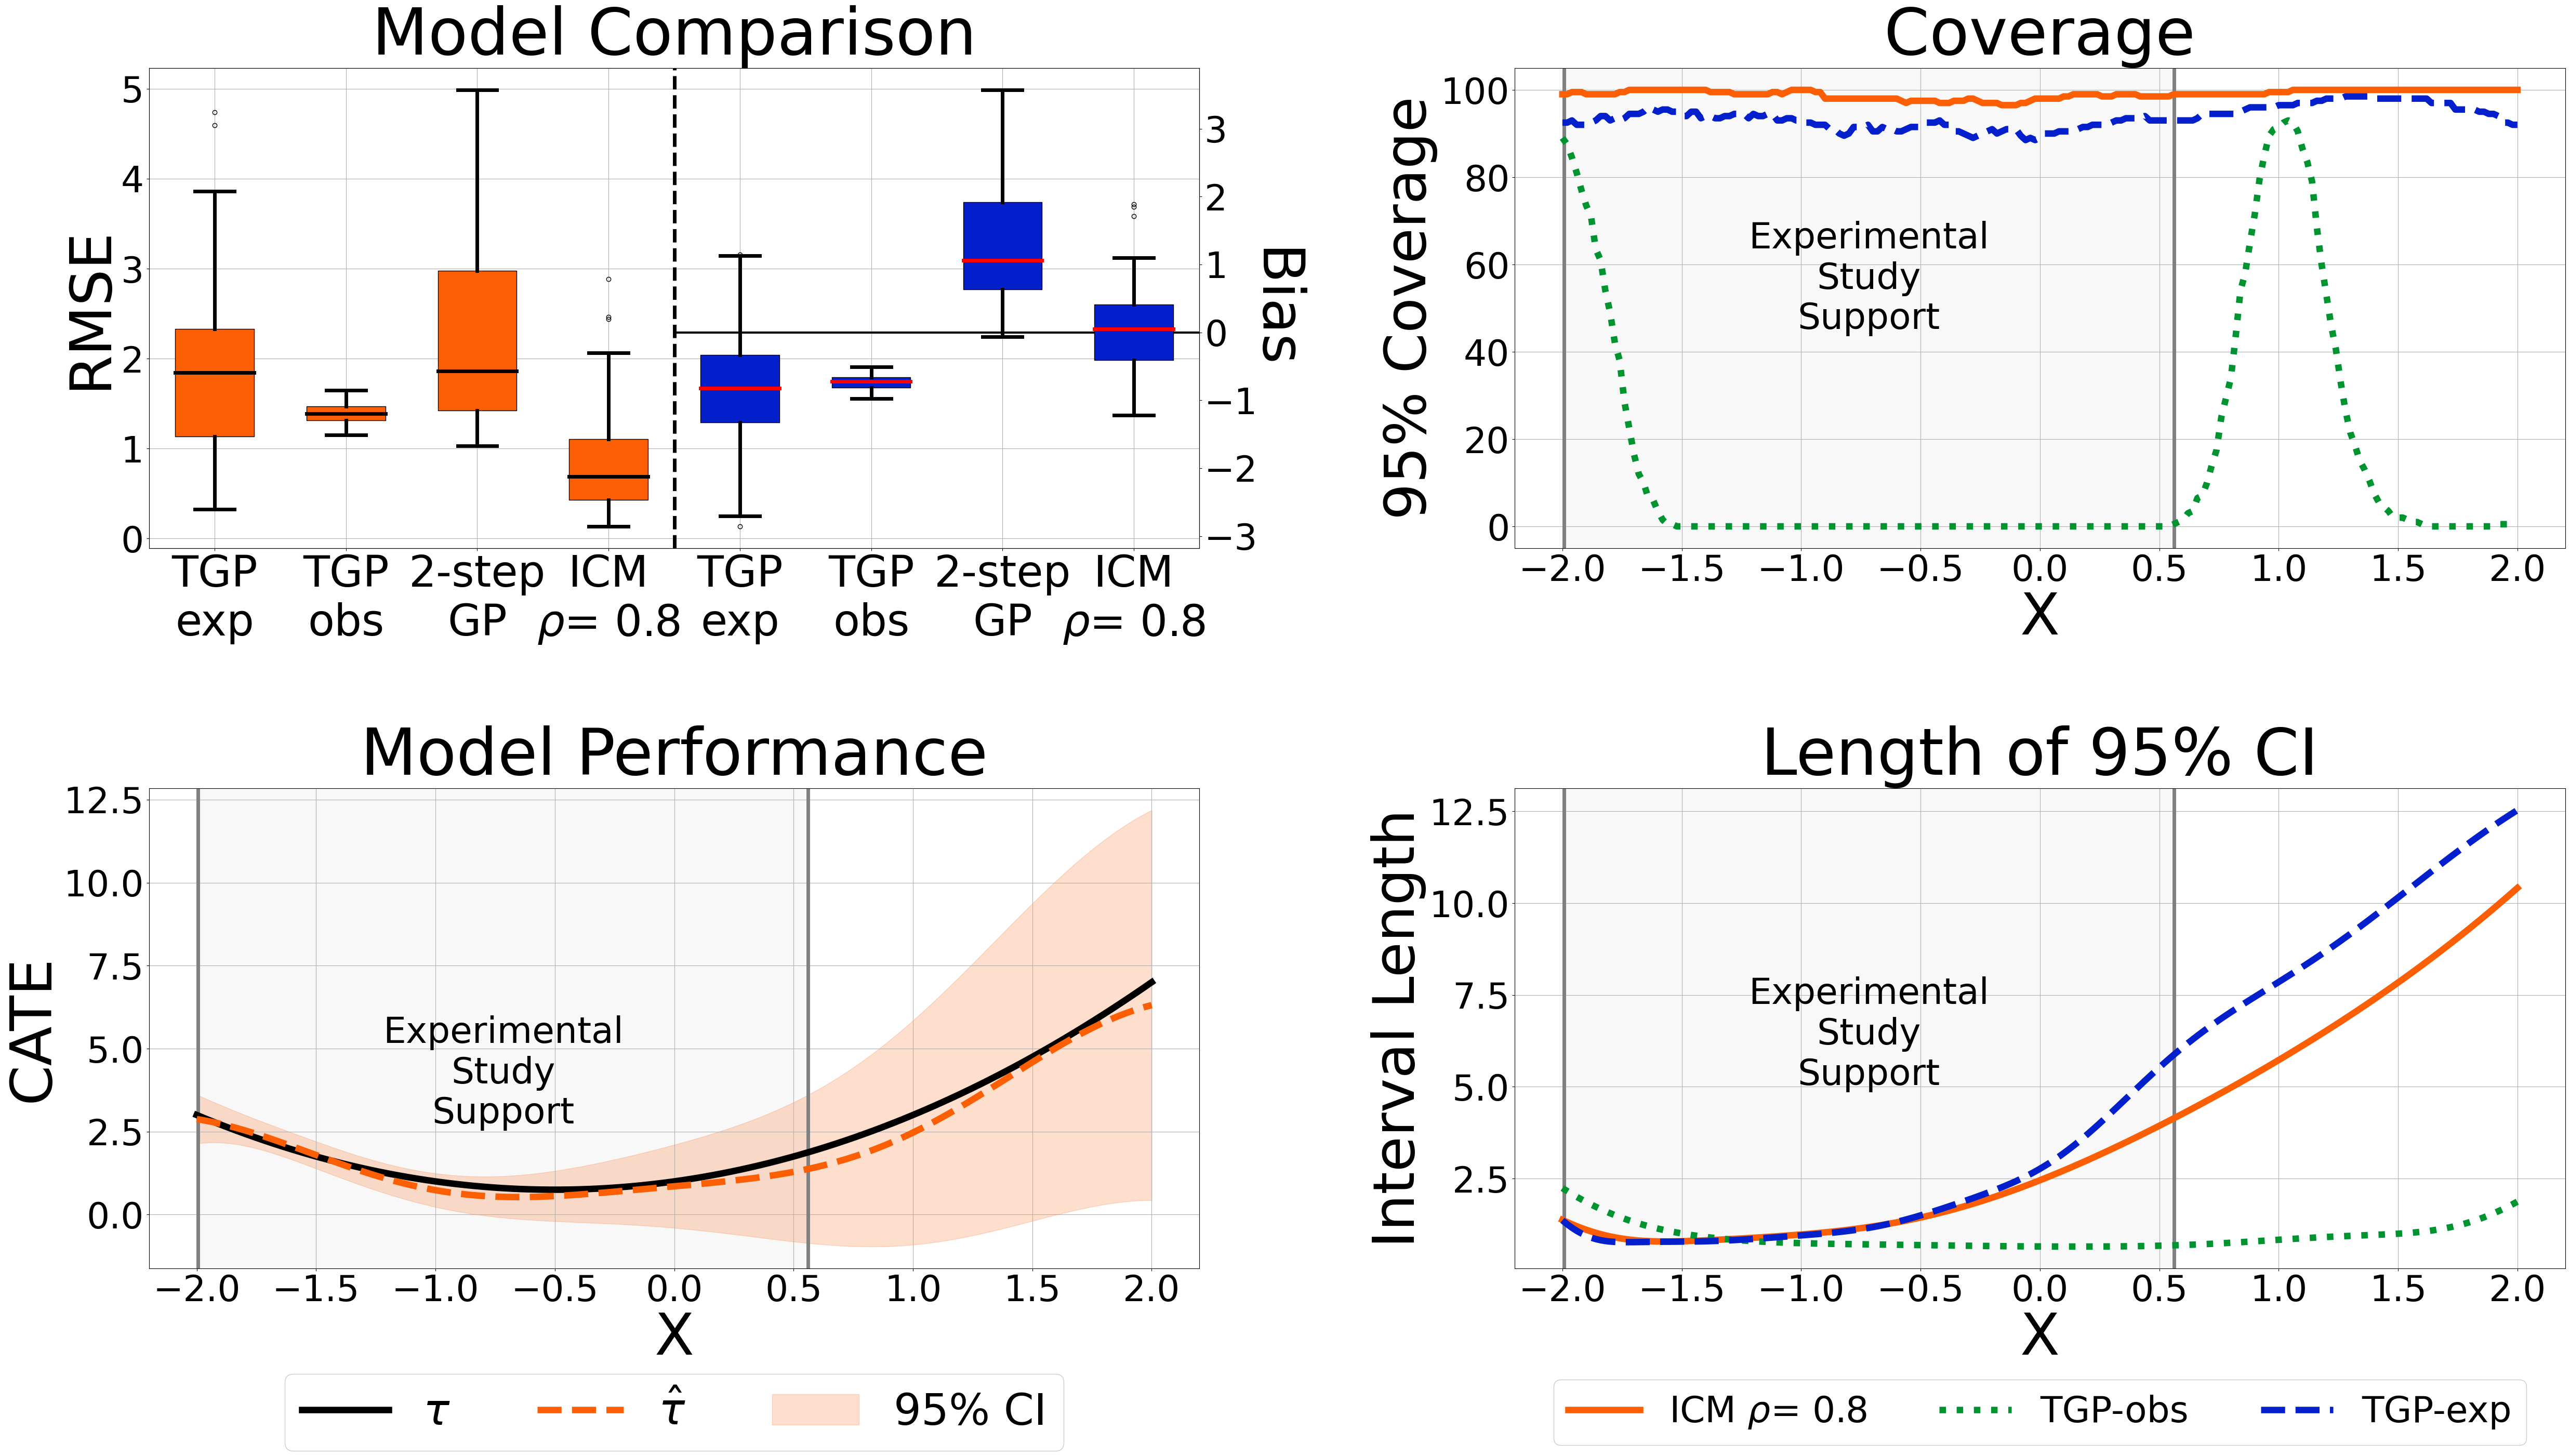

In [72]:
import matplotlib.pyplot as plt

# Grouped data for each model
data_sim8_modelComp = [
    sim8_modelComp['RMSE_naiveGPexp'].values,
    sim8_modelComp['RMSE_naiveGPobs'].values,
    sim8_modelComp['RMSE_KallusGP'].values,
    sim8_modelComp['RMSE_ICM'].values,
    sim8_modelComp['bias_naiveGPexp'].values,
    sim8_modelComp['bias_naiveGPobs'].values,
    sim8_modelComp['bias_KallusGP'].values,
    sim8_modelComp['bias_ICM'].values
]

# Labels for models
labels_sim8_modelComp = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.1f}'.format(best_rho[0]),
                         'TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.1f}'.format(best_rho[0])]

# Separate indices for RMSE and bias
rmse_indices = [0, 1, 2, 3]
bias_indices = [4, 5, 6, 7]

# Set up the figure with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(60, 30))

# Plot RMSE boxplots
positions_rmse = [i for i in range(4)]
positions_bias = [i + 5 for i in range(4)]  # Increase distance between RMSE and bias boxes

ax_rmse = axes[0, 0]
box_rmse = ax_rmse.boxplot([data_sim8_modelComp[i] for i in rmse_indices], positions=positions_rmse, patch_artist=True, widths=0.6)

# Color RMSE boxplots
colors_rmse = '#fc5e03'  # Orange for RMSE
for patch in box_rmse['boxes']:
    patch.set_facecolor(colors_rmse)
for median in box_rmse['medians']:
    median.set(color='black', linewidth=5)
for whisker in box_rmse['whiskers']:
    whisker.set(color='black', linewidth=5)
for cap in box_rmse['caps']:
    cap.set(linewidth=5)

# Set x-ticks and labels for RMSE
ax_rmse.set_xticks(range(len(positions_rmse) + len(positions_bias)))
ax_rmse.set_xticklabels(labels_sim8_modelComp[:4] + labels_sim8_modelComp[4:], fontsize=40)
ax_rmse.tick_params(axis='y', labelsize=50)
ax_rmse.tick_params(axis='x', labelsize=60)
ax_rmse.set_ylabel('RMSE', fontsize=80)


# Create a twin axis for bias boxplots
ax_bias = ax_rmse.twinx()
# Add a horizontal line segment at zero covering the last 4 boxes (bias)
ax_bias.hlines(0, positions_bias[0]-0.5, positions_bias[-1]+0.5, colors='black', linewidth=3, linestyle='-')
positions_bias = [i for i in np.arange(4,8)]
box_bias = ax_bias.boxplot([data_sim8_modelComp[i] for i in bias_indices], positions=positions_bias, patch_artist=True, widths=0.6)



# Color bias boxplots
colors_bias = '#041fcc'  # Blue for bias
for patch in box_bias['boxes']:
    patch.set_facecolor(colors_bias)
for median in box_bias['medians']:
    median.set(color='red', linewidth=5)
for whisker in box_bias['whiskers']:
    whisker.set(color='black', linewidth=5)
for cap in box_bias['caps']:
    cap.set(linewidth=5)

# Set x-ticks and labels for bias
ax_bias.set_xticks(range(len(positions_rmse) + len(positions_bias)))
ax_bias.set_yticks(np.arange(-3,4))
ax_bias.set_xticklabels(labels_sim8_modelComp[:4] + labels_sim8_modelComp[4:])
ax_bias.tick_params(axis='y', labelsize=50)
ax_bias.tick_params(axis='x', labelsize=35)
ax_bias.set_ylabel('Bias', fontsize=80, rotation=270, labelpad = 60)

# Set title and labels
ax_rmse.set_title('Model Comparison', fontsize=90)
ax_rmse.grid(True)

# Add a vertical line separating the first 4 and last 4 boxes
line_pos = (positions_rmse[-1] + positions_bias[0]) / 2  # Position the line at the midpoint between the last RMSE and first bias box
ax_rmse.axvline(x=line_pos, color='black', linestyle='--', linewidth=5)


# Plot 2
axes[0, 1].axvline(x=np.min(data_exp[:, 1]), c='grey', linewidth=5.0)
axes[0, 1].axvline(x=np.max(data_exp[:, 1]), c='grey', linewidth=5.0)
axes[0, 1].axvspan(np.min(data_exp[:, 1]), np.max(data_exp[:, 1]), alpha=0.05, color='grey')
axes[0, 1].plot(sim8_coverage['test_data'], 100 * sim8_coverage['coverageProbICM95'], linewidth=9, linestyle='solid', color="#fc5e03", label='ICM $\\rho$= {:.1f}'.format(best_rho[0]))
axes[0, 1].plot(sim8_coverage['test_data'], 100 * sim8_coverage['coverageProbGPobs95'], linewidth=9, linestyle='dotted', color="#009431", label="TGP-obs")
axes[0, 1].plot(sim8_coverage['test_data'], 100 * sim8_coverage['coverageProbGPexp95'], linewidth=9, linestyle='dashed', color="#041fcc", label="TGP-exp")
axes[0, 1].text(((np.max(data_exp[:, 1]) + np.min(data_exp[:, 1])) / 2), 70, 'Experimental\nStudy\nSupport', verticalalignment='top', horizontalalignment='center', size=50)
axes[0, 1].set_xlabel('X', fontsize=80)
axes[0, 1].set_ylabel('95% Coverage', fontsize=80)
axes[0, 1].set_title("Coverage", fontsize=90)
axes[0, 1].tick_params(axis='both', which='major', labelsize=50)
axes[0, 1].grid(True)
legend = axes[0, 1].legend(fontsize=50, bbox_to_anchor=(0.5, -1.80), loc='center', ncol=3)
legend.get_frame().set_alpha(1)

# Plot 3
true_cate = 1 + test_data + test_data ** 2
list_CATE_exp = zip(*sorted(zip(*(test_data, predCATE_exp))))
list_CATE = zip(*sorted(zip(*(test_data, true_cate))))
axes[1, 0].axvline(x=np.min(data_exp[:, 1]), c='grey', linewidth=5.0)
axes[1, 0].axvline(x=np.max(data_exp[:, 1]), c='grey', linewidth=5.0)
axes[1, 0].axvspan(np.min(data_exp[:, 1]), np.max(data_exp[:, 1]), alpha=0.05, color='grey')
axes[1, 0].text(((np.max(data_exp[:, 1]) + np.min(data_exp[:, 1])) / 2), 6, 'Experimental\nStudy\nSupport', verticalalignment='top', horizontalalignment='center', size=50)
axes[1, 0].plot(*list_CATE, label='$\\tau$', c='black', linewidth=9.0)
axes[1, 0].plot(*list_CATE_exp, label='$\\hat{\\tau}$', c="#fc5e03", linewidth=9.0, linestyle='dashed')
axes[1, 0].fill_between(test_data, 
                        np.hstack(predCATE_exp - 2 * np.vstack(np.sqrt(varCATE_exp))), 
                        np.hstack(predCATE_exp + 2 * np.vstack(np.sqrt(varCATE_exp))),
                        color="#fc5e03", alpha=0.2, label='95% CI')
axes[1, 0].set_title("Model Performance", fontsize=90)
axes[1, 0].set_xlabel("X", fontsize=80)
axes[1, 0].set_ylabel("CATE", fontsize=80)
axes[1, 0].tick_params(axis='both', which='major', labelsize=50)
axes[1, 0].grid(True)
legend = axes[1, 0].legend(fontsize=60, bbox_to_anchor=(0.5, -0.30), loc='center', ncol=3)
legend.get_frame().set_alpha(1)

# Plot 4
axes[1, 1].axvline(x=np.min(data_exp[:, 1]), c='grey', linewidth=5.0)
axes[1, 1].axvline(x=np.max(data_exp[:, 1]), c='grey', linewidth=5.0)
axes[1, 1].axvspan(np.min(data_exp[:, 1]), np.max(data_exp[:, 1]), alpha=0.05, color='grey')
axes[1, 1].plot(sim8_length['test_data'], sim8_length['length_ICM95'], linewidth=9, linestyle='solid', color="#fc5e03", label='ICM')
axes[1, 1].plot(sim8_length['test_data'], sim8_length['length_GPobs95'], linewidth=9, linestyle='dotted', color="#009431", label="GP T-learner - obs")
axes[1, 1].plot(sim8_length['test_data'], sim8_length['length_GPexp95'], linewidth=9, linestyle='dashed', color="#041fcc", label="GP T-learner - exp")
axes[1, 1].text(((np.max(data_exp[:, 1]) + np.min(data_exp[:, 1])) / 2), 8, 'Experimental\nStudy\nSupport', verticalalignment='top', horizontalalignment='center', size=50)
axes[1, 1].set_xlabel('X', fontsize=80)
axes[1, 1].set_ylabel('Interval Length', fontsize=80)
axes[1, 1].set_title("Length of 95% CI", fontsize=90)
axes[1, 1].tick_params(axis='both', which='major', labelsize=50)
axes[1, 1].grid(True)

plt.subplots_adjust(hspace=0.5, wspace=0.30)
plt.show()


In [164]:
import pandas as pd
sim1_modelComp = pd.read_csv('/Simulation1/sim1_modelComparison.csv')
sim2_modelComp = pd.read_csv('/Simulation2/sim2_modelComparison.csv')
sim3_modelComp = pd.read_csv('/Simulation3/sim3_modelComparison.csv')
sim4_modelComp = pd.read_csv('/Simulation4/sim4_modelComparison.csv')
sim5_modelComp = pd.read_csv('/Simulation5/sim5_modelComparison.csv')
sim6_modelComp = pd.read_csv('/Simulation6/sim6_modelComparison.csv')
sim7_modelComp = pd.read_csv('/Simulation7/sim7_modelComparison.csv')
sim8_modelComp = pd.read_csv('/Simulation8/sim8_modelComparison.csv')

In [165]:
best_rho1= pd.read_csv('/Simulation1/sim1_best_rho.csv').values[0]
best_rho2= pd.read_csv('/Simulation2/sim2_best_rho.csv').values[0]
best_rho3= pd.read_csv('/Simulation3/sim3_best_rho.csv').values[0]
best_rho4= pd.read_csv('Simulation4/sim4_best_rho.csv').values[0]
best_rho5= pd.read_csv('Simulation5/sim5_best_rho.csv').values[0]
best_rho6= pd.read_csv('Simulation6/sim6_best_rho.csv').values[0]
best_rho7= pd.read_csv('/Simulation7/sim7_best_rho.csv').values[0]
best_rho8= pd.read_csv('/Simulation8/sim8_best_rho.csv').values[0]


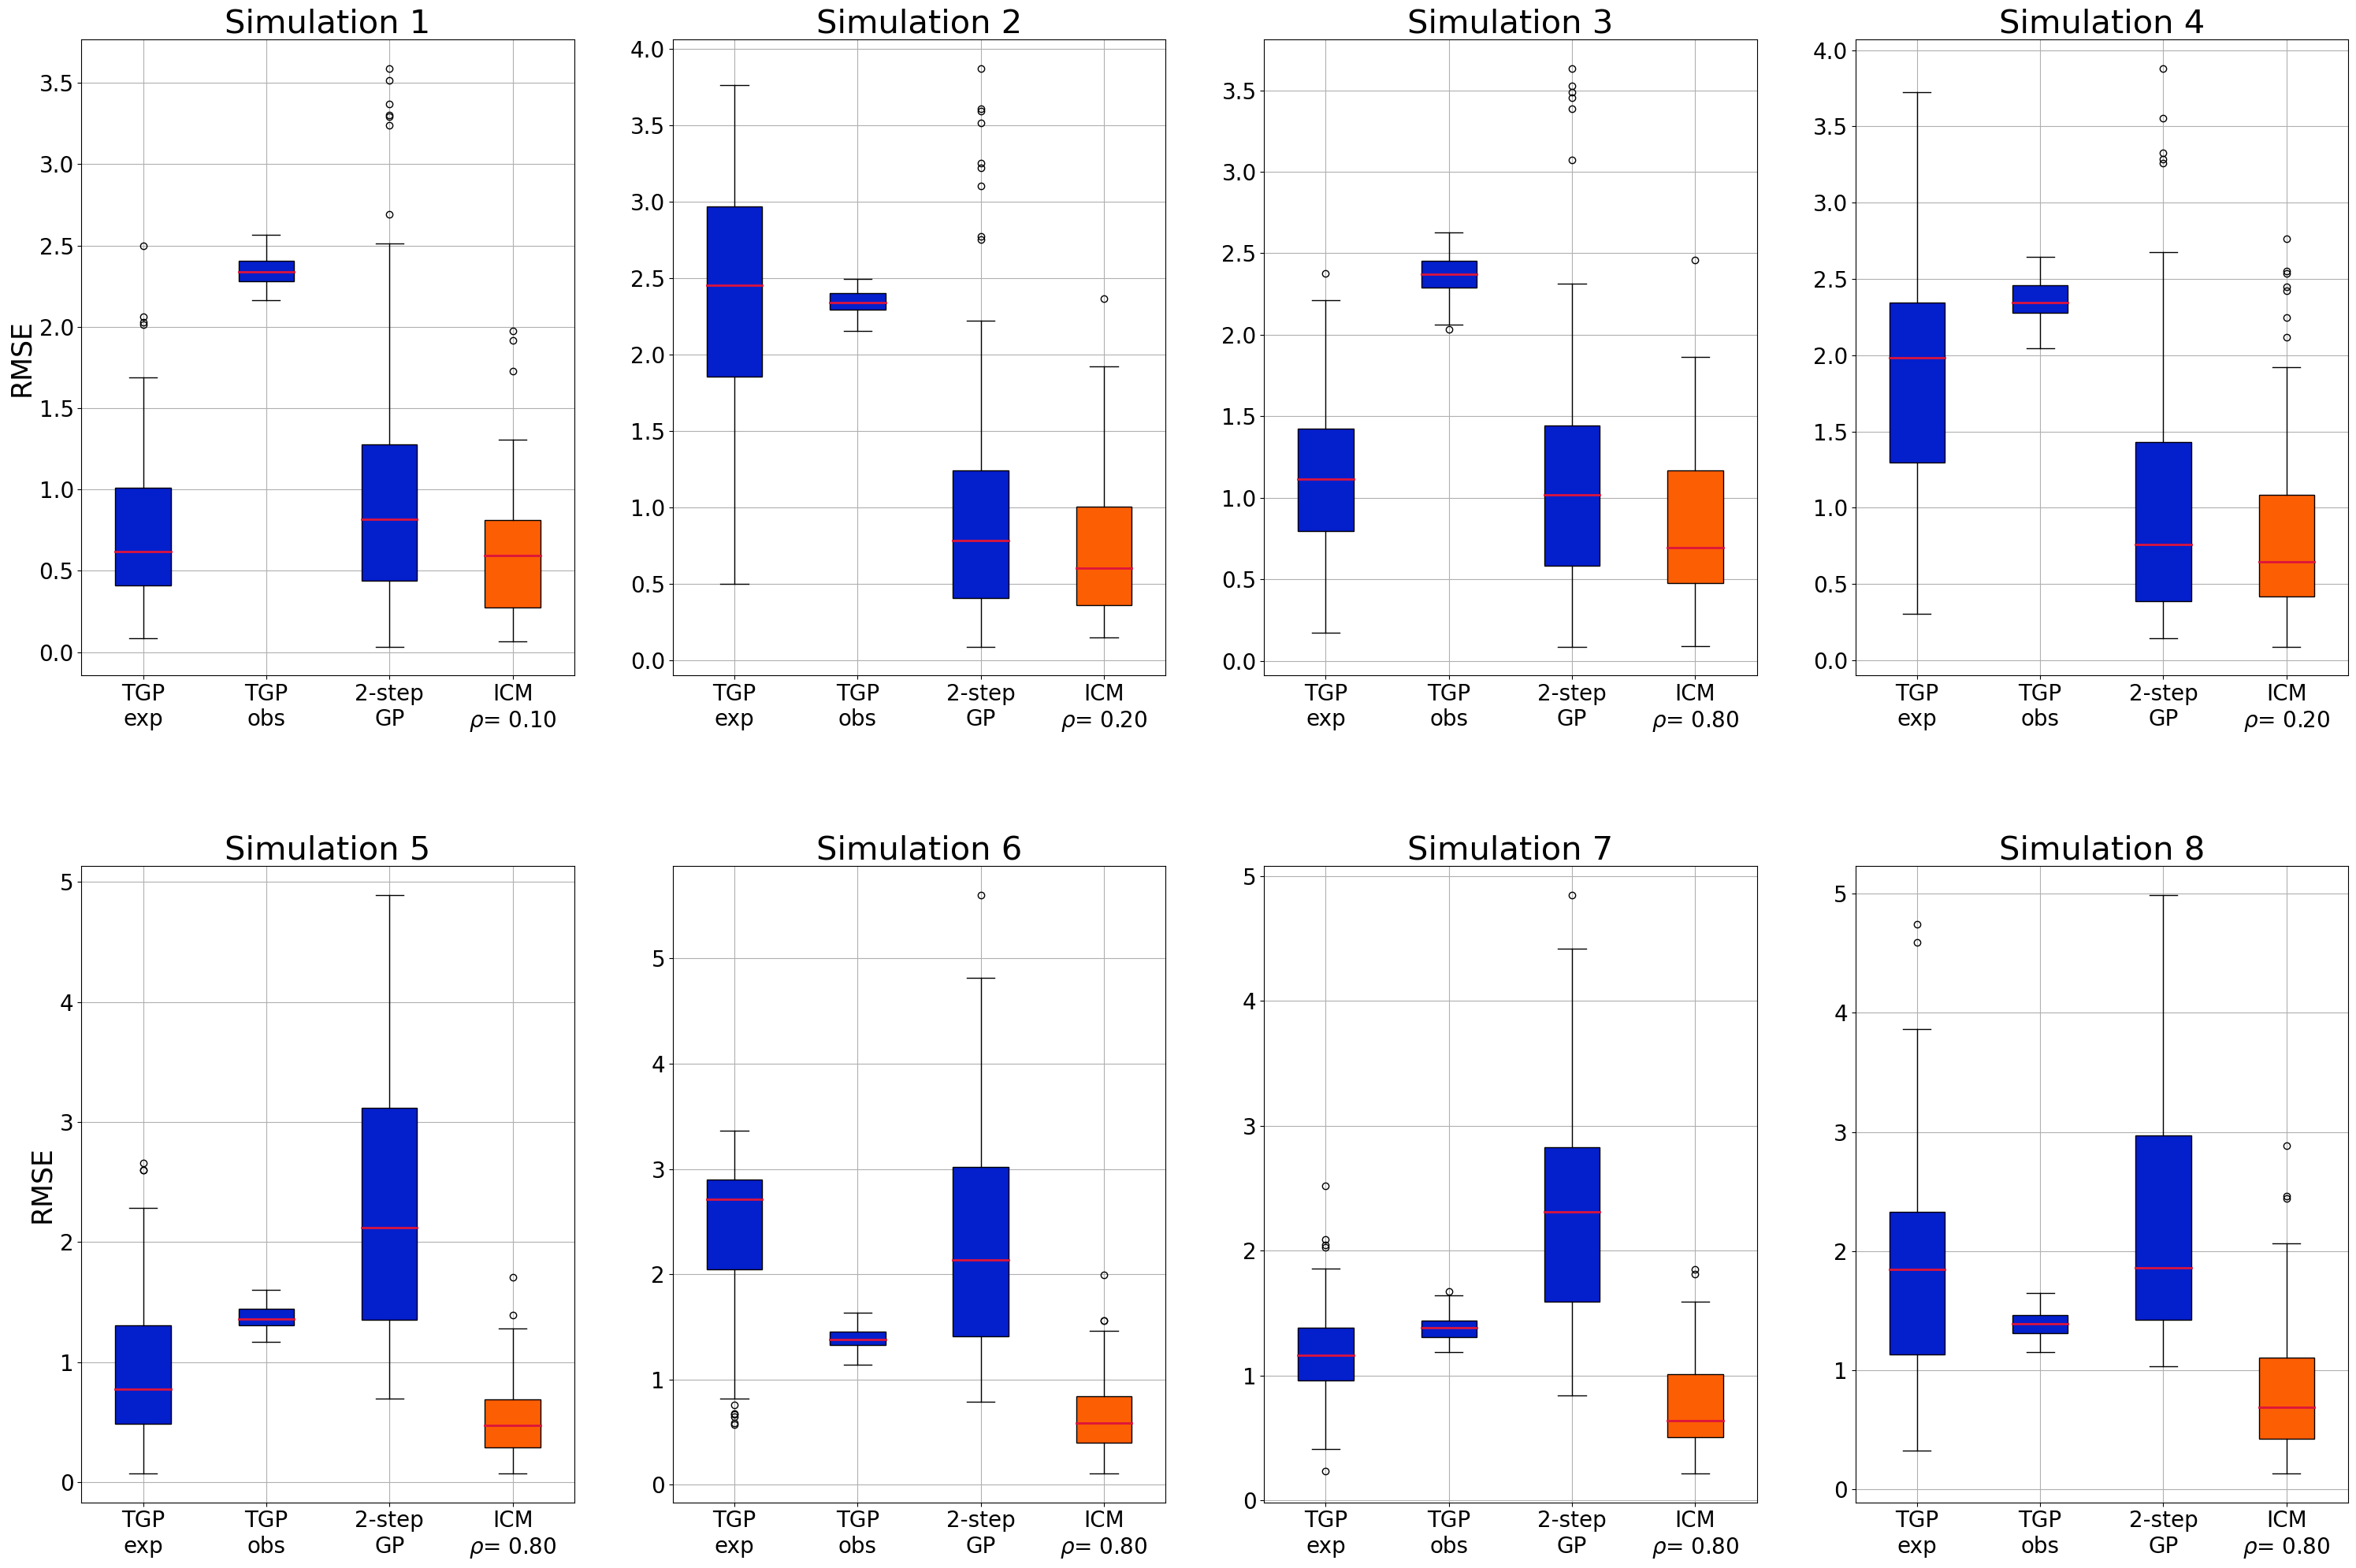

In [168]:
import matplotlib.pyplot as plt

# Data and labels for the first subplot
data_sim1 = [sim1_modelComp['RMSE_naiveGPexp'].values, 
             sim1_modelComp['RMSE_naiveGPobs'].values, 
             sim1_modelComp['RMSE_KallusGP'].values, 
             sim1_modelComp['RMSE_ICM'].values]
labels_sim1 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho1[0])]

# Data and labels for the second subplot
data_sim2 = [sim2_modelComp['RMSE_naiveGPexp'].values, 
             sim2_modelComp['RMSE_naiveGPobs'].values, 
             sim2_modelComp['RMSE_KallusGP'].values, 
             sim2_modelComp['RMSE_ICM'].values]
labels_sim2 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho2[0])]

# Data and labels for the second subplot
data_sim3 = [sim3_modelComp['RMSE_naiveGPexp'].values, 
             sim3_modelComp['RMSE_naiveGPobs'].values, 
             sim3_modelComp['RMSE_KallusGP'].values, 
             sim3_modelComp['RMSE_ICM'].values]
labels_sim3 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho3[0])]

# Data and labels for the second subplot
data_sim4 = [sim4_modelComp['RMSE_naiveGPexp'].values, 
             sim4_modelComp['RMSE_naiveGPobs'].values, 
             sim4_modelComp['RMSE_KallusGP'].values, 
             sim4_modelComp['RMSE_ICM'].values]
labels_sim4 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho4[0])]

# Data and labels for the second subplot
data_sim5 = [sim5_modelComp['RMSE_naiveGPexp'].values, 
             sim5_modelComp['RMSE_naiveGPobs'].values, 
             sim5_modelComp['RMSE_KallusGP'].values, 
             sim5_modelComp['RMSE_ICM'].values]
labels_sim5 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho5[0])]

# Data and labels for the second subplot
data_sim6 = [sim6_modelComp['RMSE_naiveGPexp'].values, 
             sim6_modelComp['RMSE_naiveGPobs'].values, 
             sim6_modelComp['RMSE_KallusGP'].values, 
             sim6_modelComp['RMSE_ICM'].values]
labels_sim6 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho6[0])]

# Data and labels for the second subplot
data_sim7 = [sim7_modelComp['RMSE_naiveGPexp'].values, 
             sim7_modelComp['RMSE_naiveGPobs'].values, 
             sim7_modelComp['RMSE_KallusGP'].values, 
             sim7_modelComp['RMSE_ICM'].values]
labels_sim7 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho7[0])]

# Data and labels for the second subplot
data_sim8 = [sim8_modelComp['RMSE_naiveGPexp'].values, 
             sim8_modelComp['RMSE_naiveGPobs'].values, 
             sim8_modelComp['RMSE_KallusGP'].values, 
             sim8_modelComp['RMSE_ICM'].values]
labels_sim8 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho8[0])]

# Create a figure with two subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(30, 20))

# Plotting the subplot 1
box1 = axes[0,0].boxplot(data_sim1, patch_artist=True, labels=labels_sim1)
colors = ['#041fcc', '#041fcc', '#041fcc', '#fc5e03']
for patch, color in zip(box1['boxes'], colors):
    patch.set_facecolor(color)
for median in box1['medians']:
    median.set(color='crimson', linewidth=2)
axes[0,0].set_ylabel('RMSE', fontsize=25)
axes[0,0].set_title("Simulation 1", fontsize=30, loc='center')
axes[0,0].grid(True)
axes[0,0].set_xticklabels(labels_sim1, size = 20)


# Plotting the subplot 2
box2 = axes[0,1].boxplot(data_sim2, patch_artist=True, labels=labels_sim2)
for patch, color in zip(box2['boxes'], colors):
    patch.set_facecolor(color)
for median in box2['medians']:
    median.set(color='crimson', linewidth=2)
axes[0,1].set_title("Simulation 2", fontsize=30, loc='center')
axes[0,1].grid(True)
axes[0,1].set_xticklabels(labels_sim2, size = 20)

# Plotting the subplot 3
box3 = axes[0,2].boxplot(data_sim3, patch_artist=True, labels=labels_sim3)
for patch, color in zip(box3['boxes'], colors):
    patch.set_facecolor(color)
for median in box3['medians']:
    median.set(color='crimson', linewidth=2)
axes[0,2].set_title("Simulation 3", fontsize=30, loc='center')
axes[0,2].grid(True)
axes[0,2].set_xticklabels(labels_sim3, size = 20)

# Plotting the subplot 4
box4 = axes[0,3].boxplot(data_sim4, patch_artist=True, labels=labels_sim4)
for patch, color in zip(box4['boxes'], colors):
    patch.set_facecolor(color)
for median in box4['medians']:
    median.set(color='crimson', linewidth=2)
axes[0,3].set_title("Simulation 4", fontsize=30, loc='center')
axes[0,3].grid(True)
axes[0,3].set_xticklabels(labels_sim4, size = 20)

# Plotting the subplot 5
box5 = axes[1,0].boxplot(data_sim5, patch_artist=True, labels=labels_sim5)
for patch, color in zip(box5['boxes'], colors):
    patch.set_facecolor(color)
for median in box5['medians']:
    median.set(color='crimson', linewidth=2)
axes[1,0].set_ylabel('RMSE', fontsize=25)
axes[1,0].set_title("Simulation 5", fontsize=30, loc='center')
axes[1,0].grid(True)
axes[1,0].set_xticklabels(labels_sim5, size = 20)

# Plotting the subplot 6
box6 = axes[1,1].boxplot(data_sim6, patch_artist=True, labels=labels_sim6)
for patch, color in zip(box6['boxes'], colors):
    patch.set_facecolor(color)
for median in box6['medians']:
    median.set(color='crimson', linewidth=2)
axes[1,1].set_title("Simulation 6", fontsize=30, loc='center')
axes[1,1].grid(True)
axes[1,1].set_xticklabels(labels_sim6, size = 20)

# Plotting the subplot 7
box7 = axes[1,2].boxplot(data_sim7, patch_artist=True, labels=labels_sim7)
for patch, color in zip(box7['boxes'], colors):
    patch.set_facecolor(color)
for median in box7['medians']:
    median.set(color='crimson', linewidth=2)
axes[1,2].set_title("Simulation 7", fontsize=30, loc='center')
axes[1,2].grid(True)
axes[1,2].set_xticklabels(labels_sim7, size = 20)

# Plotting the subplot 8
box8 = axes[1,3].boxplot(data_sim8, patch_artist=True, labels=labels_sim8)
for patch, color in zip(box8['boxes'], colors):
    patch.set_facecolor(color)
for median in box8['medians']:
    median.set(color='crimson', linewidth=2)
axes[1,3].set_title("Simulation 8", fontsize=30, loc='center')
axes[1,3].grid(True)
axes[1,3].set_xticklabels(labels_sim8, size = 20)

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis='y', labelsize=20)  # Adjust the labelsize as needed

# Adjust layout
plt.tight_layout()

# Space between row 1 and row 2
plt.subplots_adjust(hspace=0.3, wspace=0.2)


plt.show()


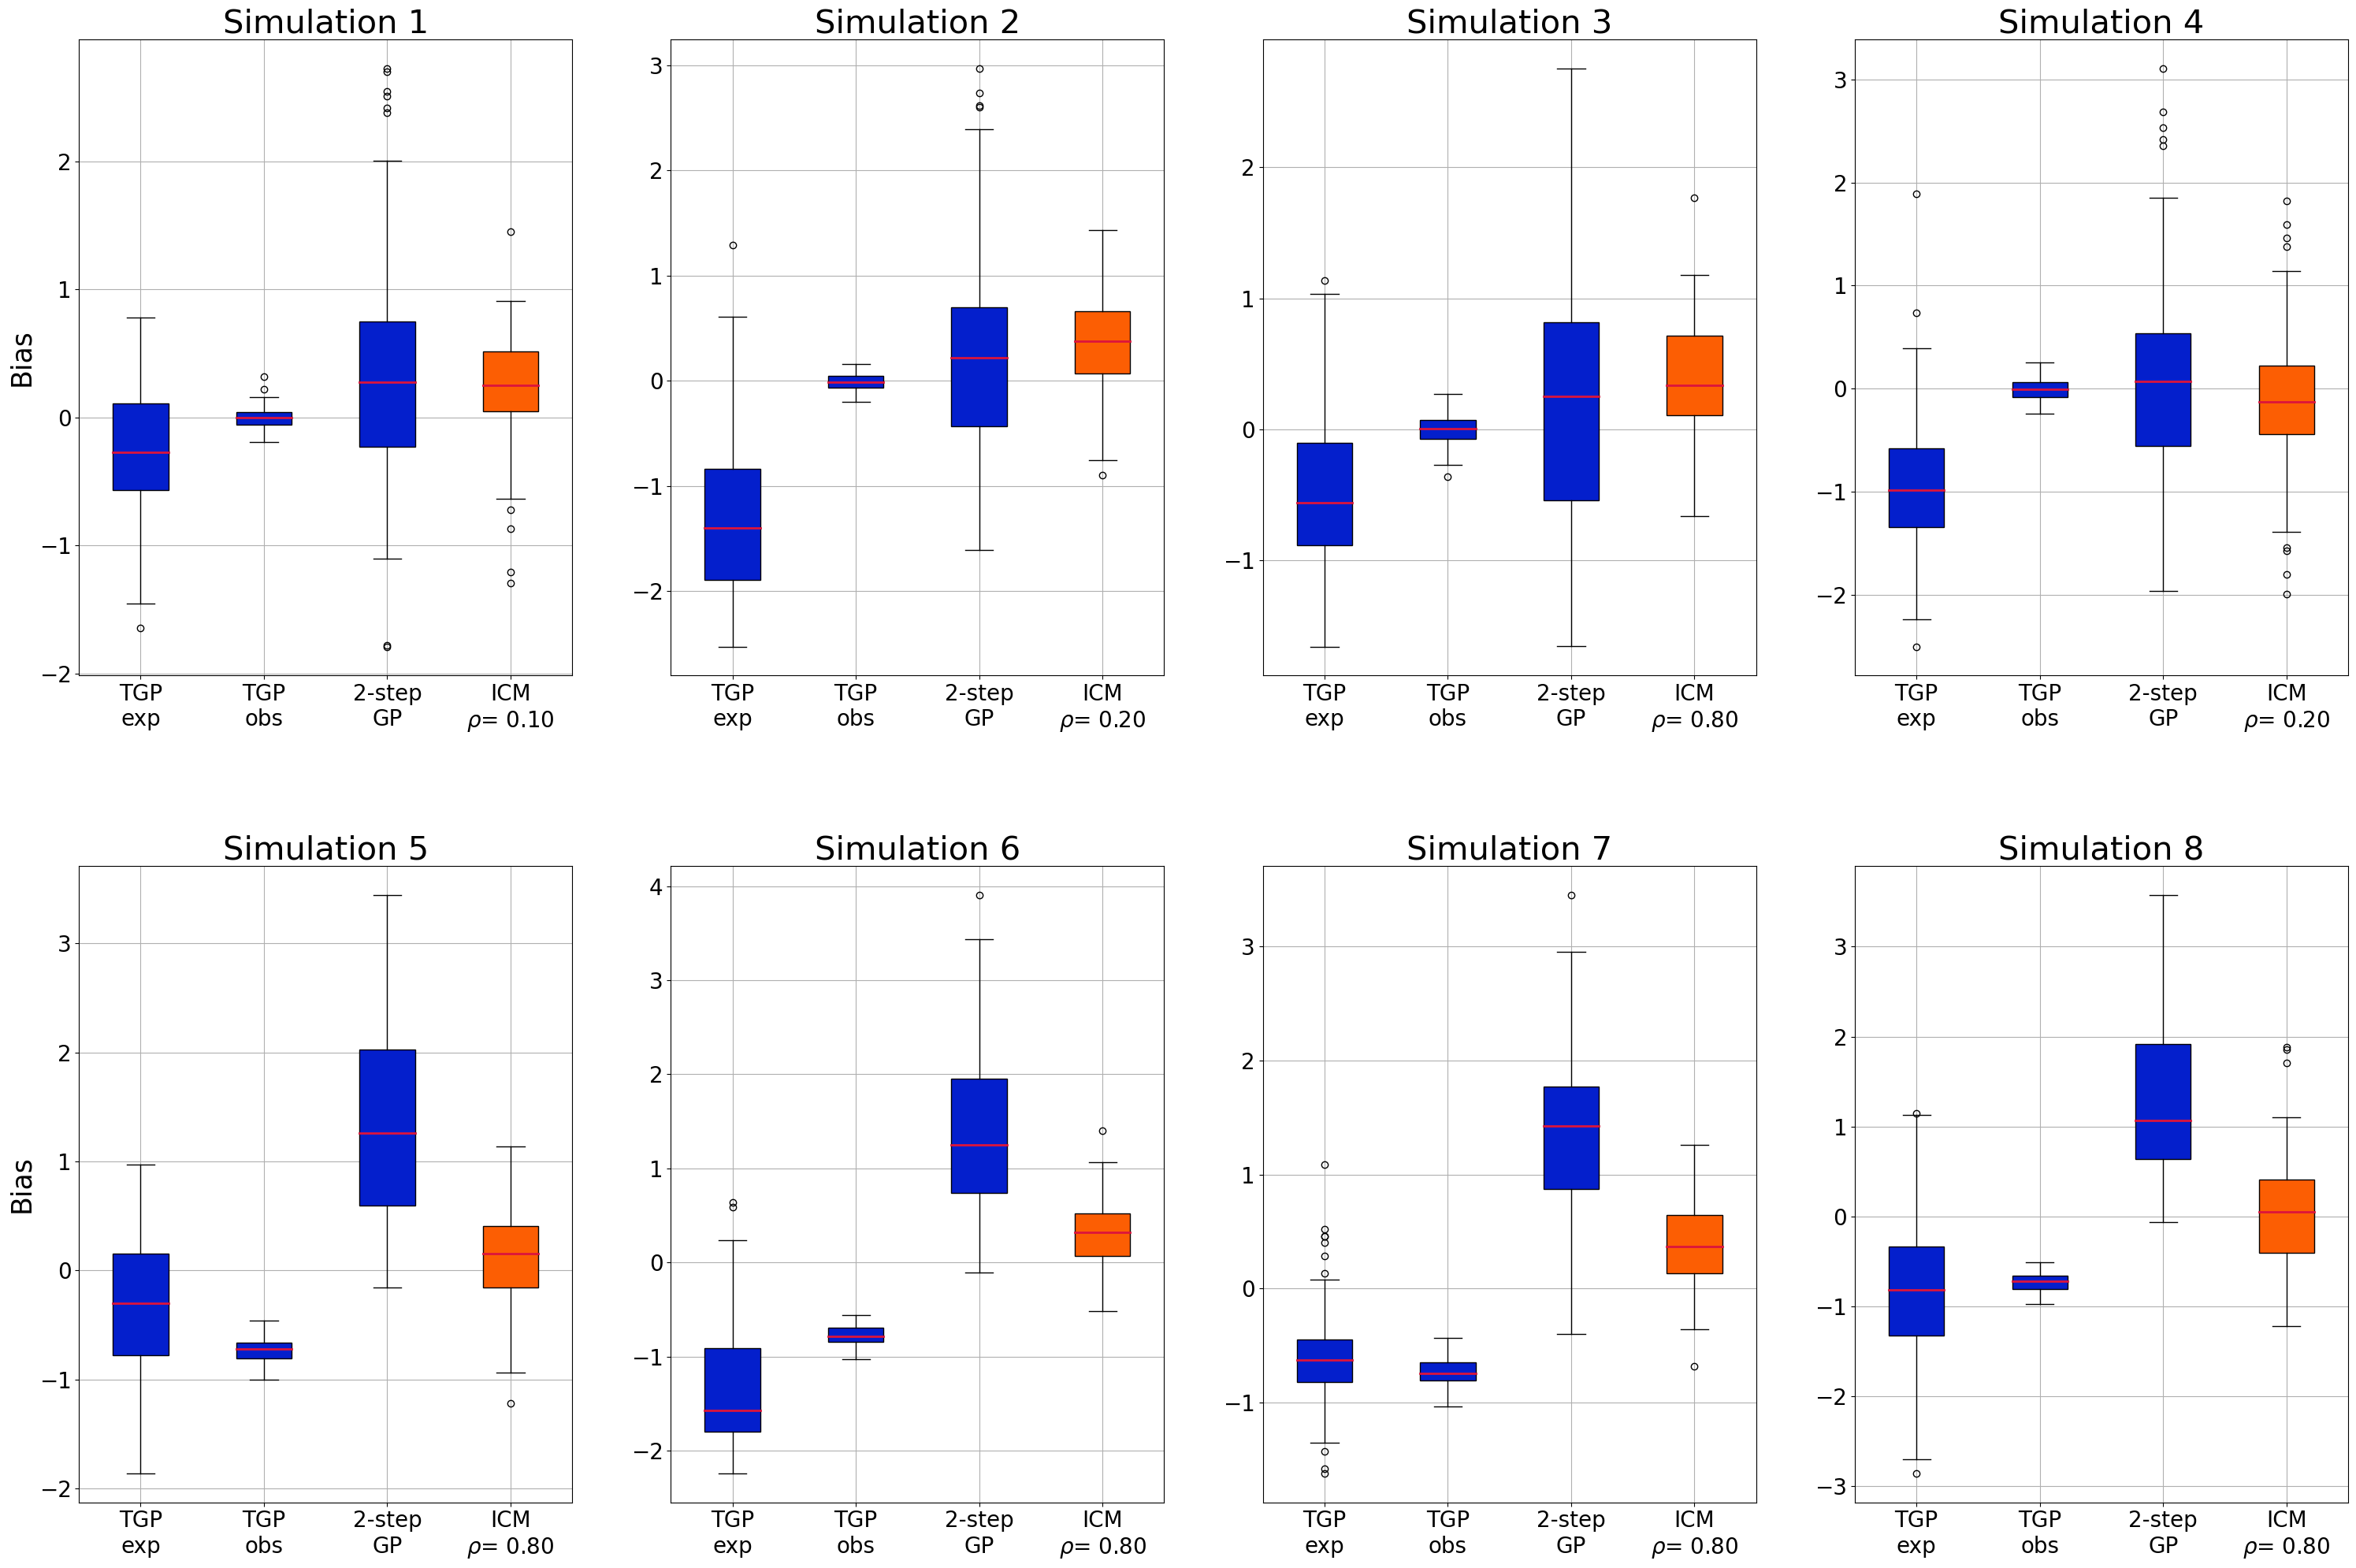

In [169]:
import matplotlib.pyplot as plt

# Data and labels for the first subplot
data_sim1 = [sim1_modelComp['bias_naiveGPexp'].values, 
             sim1_modelComp['bias_naiveGPobs'].values, 
             sim1_modelComp['bias_KallusGP'].values, 
             sim1_modelComp['bias_ICM'].values]
labels_sim1 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho1[0])]

# Data and labels for the second subplot
data_sim2 = [sim2_modelComp['bias_naiveGPexp'].values, 
             sim2_modelComp['bias_naiveGPobs'].values, 
             sim2_modelComp['bias_KallusGP'].values, 
             sim2_modelComp['bias_ICM'].values]
labels_sim2 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho2[0])]

# Data and labels for the second subplot
data_sim3 = [sim3_modelComp['bias_naiveGPexp'].values, 
             sim3_modelComp['bias_naiveGPobs'].values, 
             sim3_modelComp['bias_KallusGP'].values, 
             sim3_modelComp['bias_ICM'].values]
labels_sim3 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho3[0])]

# Data and labels for the second subplot
data_sim4 = [sim4_modelComp['bias_naiveGPexp'].values, 
             sim4_modelComp['bias_naiveGPobs'].values, 
             sim4_modelComp['bias_KallusGP'].values, 
             sim4_modelComp['bias_ICM'].values]
labels_sim4 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho4[0])]

# Data and labels for the second subplot
data_sim5 = [sim5_modelComp['bias_naiveGPexp'].values, 
             sim5_modelComp['bias_naiveGPobs'].values, 
             sim5_modelComp['bias_KallusGP'].values, 
             sim5_modelComp['bias_ICM'].values]
labels_sim5 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho5[0])]

# Data and labels for the second subplot
data_sim6 = [sim6_modelComp['bias_naiveGPexp'].values, 
             sim6_modelComp['bias_naiveGPobs'].values, 
             sim6_modelComp['bias_KallusGP'].values, 
             sim6_modelComp['bias_ICM'].values]
labels_sim6 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho6[0])]

# Data and labels for the second subplot
data_sim7 = [sim7_modelComp['bias_naiveGPexp'].values, 
             sim7_modelComp['bias_naiveGPobs'].values, 
             sim7_modelComp['bias_KallusGP'].values, 
             sim7_modelComp['bias_ICM'].values]
labels_sim7 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho7[0])]

# Data and labels for the second subplot
data_sim8 = [sim8_modelComp['bias_naiveGPexp'].values, 
             sim8_modelComp['bias_naiveGPobs'].values, 
             sim8_modelComp['bias_KallusGP'].values, 
             sim8_modelComp['bias_ICM'].values]
labels_sim8 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho8[0])]

# Create a figure with two subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(30, 20))

# Plotting the subplot 1
box1 = axes[0,0].boxplot(data_sim1, patch_artist=True, labels=labels_sim1)
colors = ['#041fcc', '#041fcc', '#041fcc', '#fc5e03']
for patch, color in zip(box1['boxes'], colors):
    patch.set_facecolor(color)
for median in box1['medians']:
    median.set(color='crimson', linewidth=2)
axes[0,0].set_ylabel('Bias', fontsize=25)
axes[0,0].set_title("Simulation 1", fontsize=30, loc='center')
axes[0,0].grid(True)
axes[0,0].set_xticklabels(labels_sim1, size = 20)


# Plotting the subplot 2
box2 = axes[0,1].boxplot(data_sim2, patch_artist=True, labels=labels_sim2)
for patch, color in zip(box2['boxes'], colors):
    patch.set_facecolor(color)
for median in box2['medians']:
    median.set(color='crimson', linewidth=2)
axes[0,1].set_title("Simulation 2", fontsize=30, loc='center')
axes[0,1].grid(True)
axes[0,1].set_xticklabels(labels_sim2, size = 20)

# Plotting the subplot 3
box3 = axes[0,2].boxplot(data_sim3, patch_artist=True, labels=labels_sim3)
for patch, color in zip(box3['boxes'], colors):
    patch.set_facecolor(color)
for median in box3['medians']:
    median.set(color='crimson', linewidth=2)
axes[0,2].set_title("Simulation 3", fontsize=30, loc='center')
axes[0,2].grid(True)
axes[0,2].set_xticklabels(labels_sim3, size = 20)

# Plotting the subplot 4
box4 = axes[0,3].boxplot(data_sim4, patch_artist=True, labels=labels_sim4)
for patch, color in zip(box4['boxes'], colors):
    patch.set_facecolor(color)
for median in box4['medians']:
    median.set(color='crimson', linewidth=2)
axes[0,3].set_title("Simulation 4", fontsize=30, loc='center')
axes[0,3].grid(True)
axes[0,3].set_xticklabels(labels_sim4, size = 20)

# Plotting the subplot 5
box5 = axes[1,0].boxplot(data_sim5, patch_artist=True, labels=labels_sim5)
for patch, color in zip(box5['boxes'], colors):
    patch.set_facecolor(color)
for median in box5['medians']:
    median.set(color='crimson', linewidth=2)
axes[1,0].set_ylabel('Bias', fontsize=25)
axes[1,0].set_title("Simulation 5", fontsize=30, loc='center')
axes[1,0].grid(True)
axes[1,0].set_xticklabels(labels_sim5, size = 20)

# Plotting the subplot 6
box6 = axes[1,1].boxplot(data_sim6, patch_artist=True, labels=labels_sim6)
for patch, color in zip(box6['boxes'], colors):
    patch.set_facecolor(color)
for median in box6['medians']:
    median.set(color='crimson', linewidth=2)
axes[1,1].set_title("Simulation 6", fontsize=30, loc='center')
axes[1,1].grid(True)
axes[1,1].set_xticklabels(labels_sim6, size = 20)

# Plotting the subplot 7
box7 = axes[1,2].boxplot(data_sim7, patch_artist=True, labels=labels_sim7)
for patch, color in zip(box7['boxes'], colors):
    patch.set_facecolor(color)
for median in box7['medians']:
    median.set(color='crimson', linewidth=2)
axes[1,2].set_title("Simulation 7", fontsize=30, loc='center')
axes[1,2].grid(True)
axes[1,2].set_xticklabels(labels_sim7, size = 20)

# Plotting the subplot 8
box8 = axes[1,3].boxplot(data_sim8, patch_artist=True, labels=labels_sim8)
for patch, color in zip(box8['boxes'], colors):
    patch.set_facecolor(color)
for median in box8['medians']:
    median.set(color='crimson', linewidth=2)
axes[1,3].set_title("Simulation 8", fontsize=30, loc='center')
axes[1,3].grid(True)
axes[1,3].set_xticklabels(labels_sim8, size = 20)

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis='y', labelsize=20)  # Adjust the labelsize as needed

# Adjust layout
plt.tight_layout()

# Space between row 1 and row 2
plt.subplots_adjust(hspace=0.3, wspace=0.2)


plt.show()


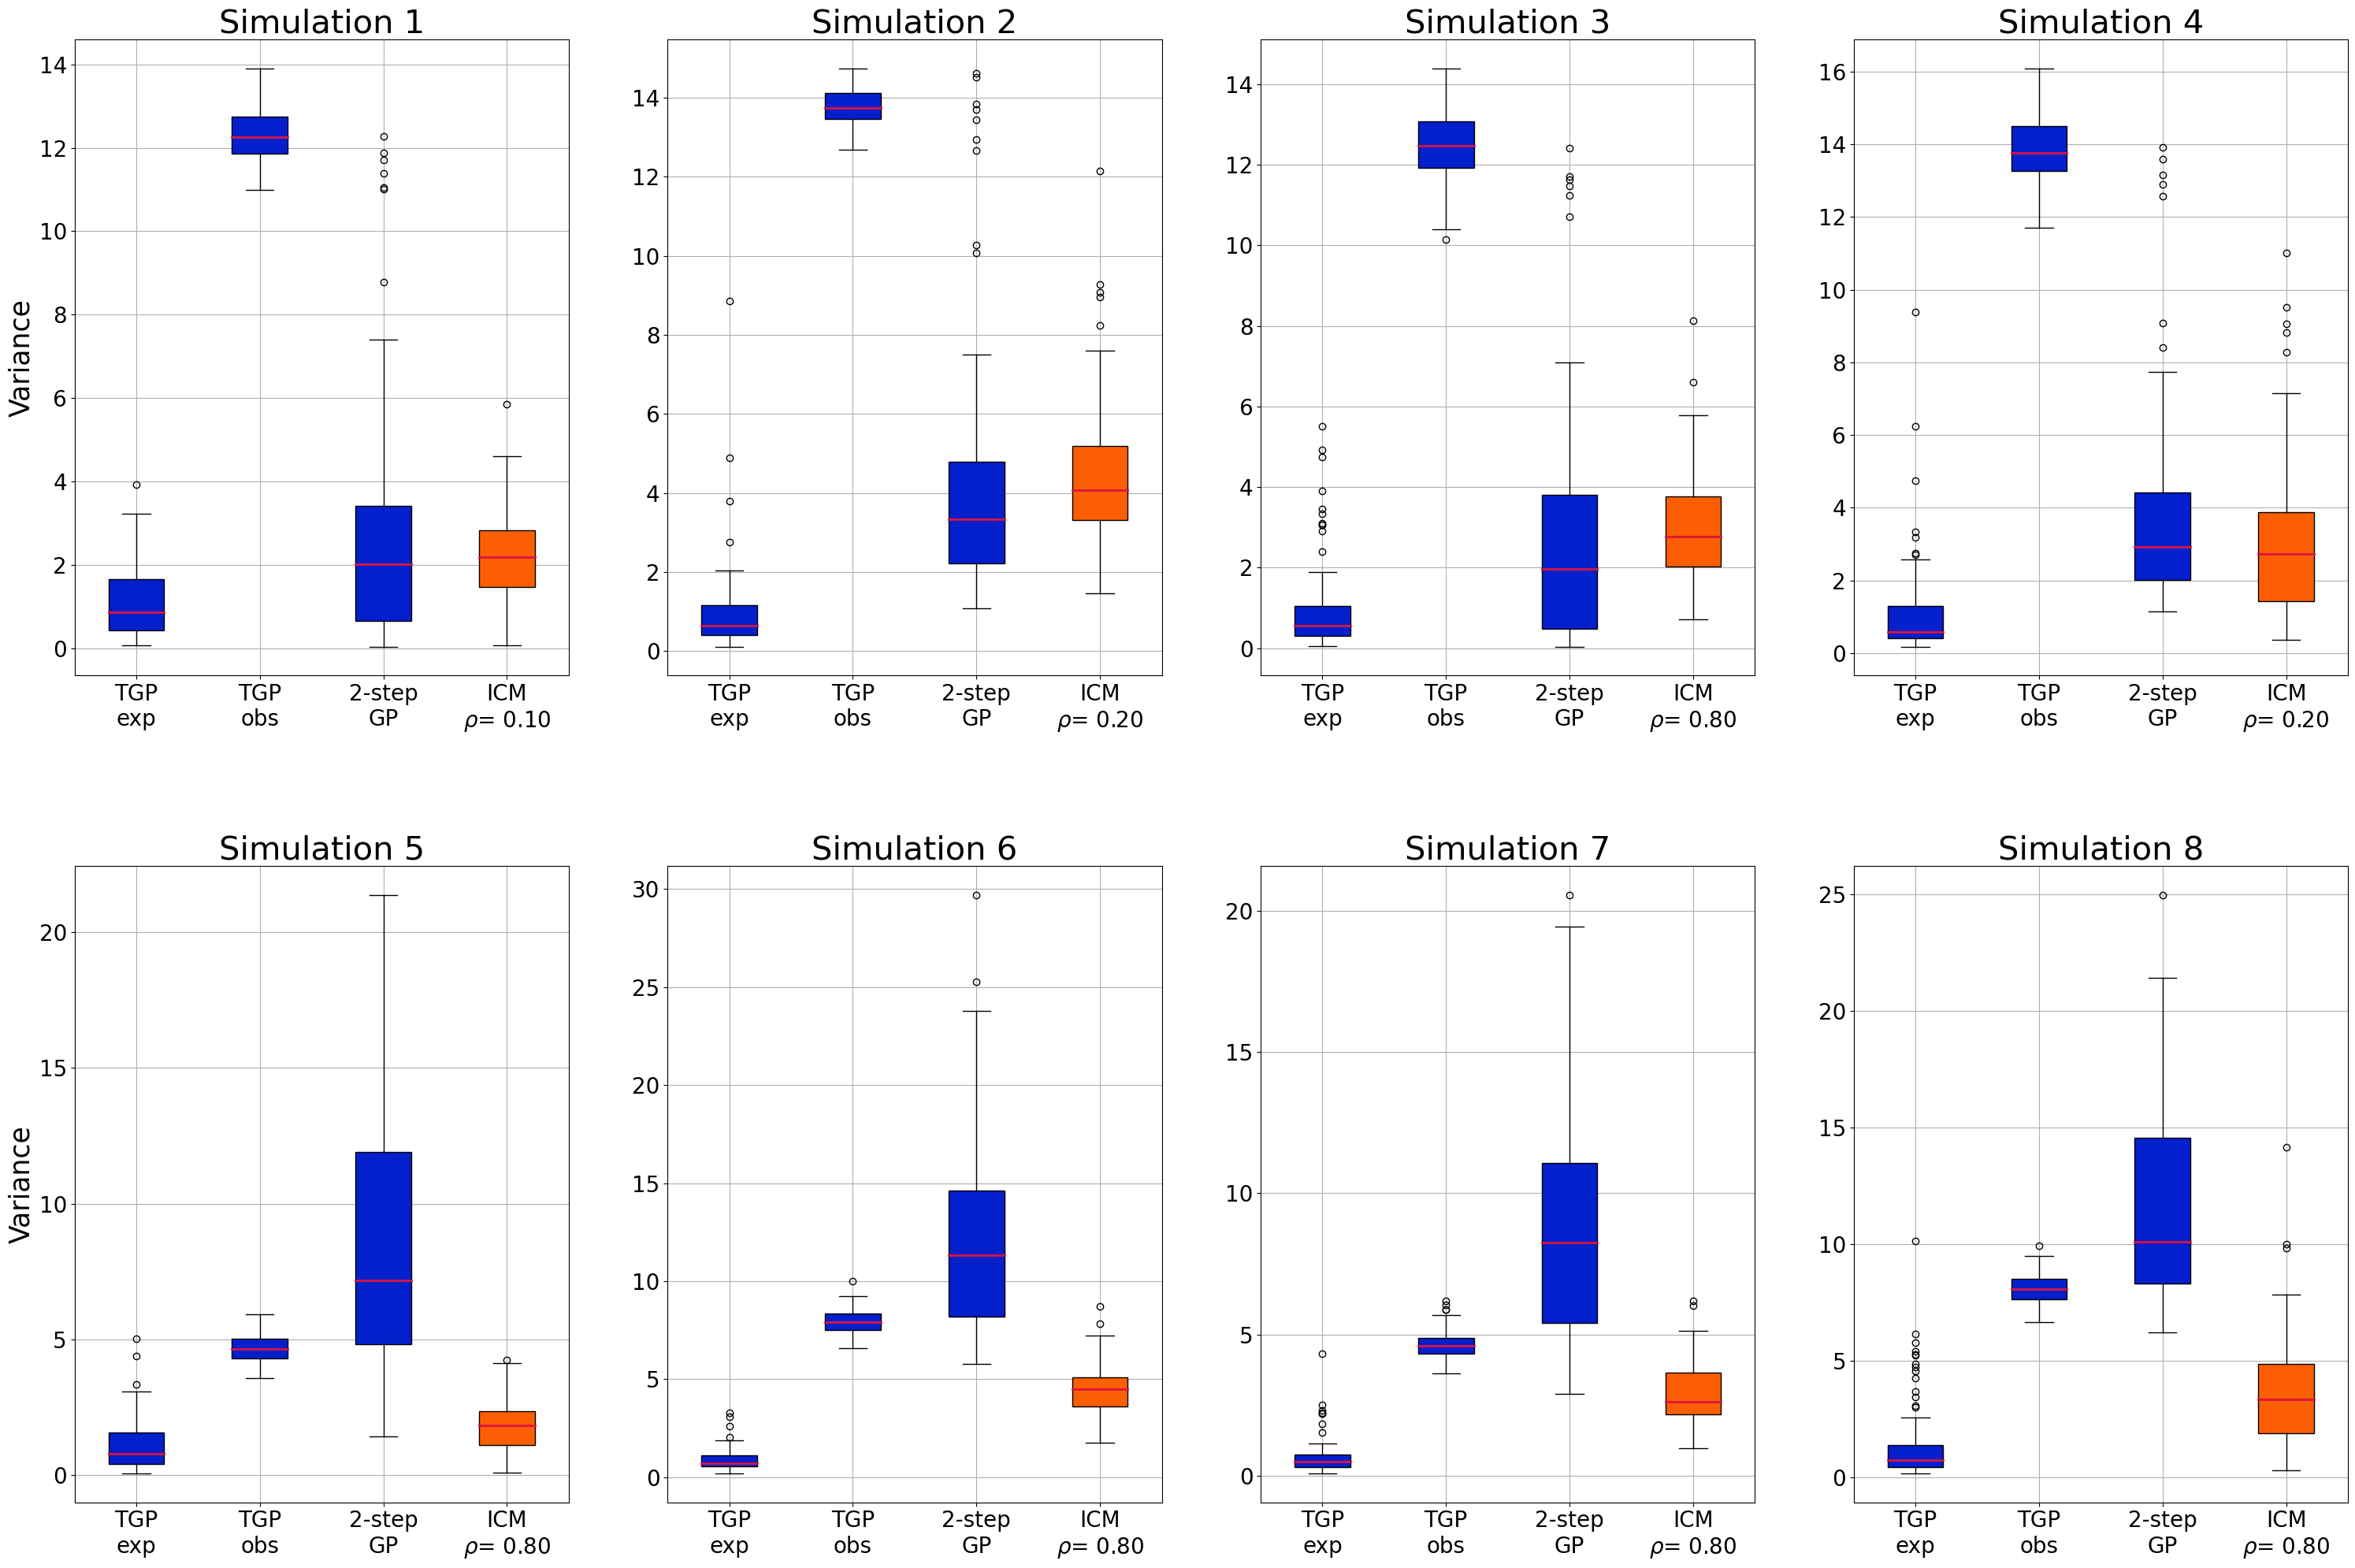

In [170]:
import matplotlib.pyplot as plt

# Data and labels for the first subplot
data_sim1 = [sim1_modelComp['var_naiveGPexp'].values, 
             sim1_modelComp['var_naiveGPobs'].values, 
             sim1_modelComp['var_KallusGP'].values, 
             sim1_modelComp['var_ICM'].values]
labels_sim1 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho1[0])]

# Data and labels for the second subplot
data_sim2 = [sim2_modelComp['var_naiveGPexp'].values, 
             sim2_modelComp['var_naiveGPobs'].values, 
             sim2_modelComp['var_KallusGP'].values, 
             sim2_modelComp['var_ICM'].values]
labels_sim2 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho2[0])]

# Data and labels for the second subplot
data_sim3 = [sim3_modelComp['var_naiveGPexp'].values, 
             sim3_modelComp['var_naiveGPobs'].values, 
             sim3_modelComp['var_KallusGP'].values, 
             sim3_modelComp['var_ICM'].values]
labels_sim3 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho3[0])]

# Data and labels for the second subplot
data_sim4 = [sim4_modelComp['var_naiveGPexp'].values, 
             sim4_modelComp['var_naiveGPobs'].values, 
             sim4_modelComp['var_KallusGP'].values, 
             sim4_modelComp['var_ICM'].values]
labels_sim4 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho4[0])]

# Data and labels for the second subplot
data_sim5 = [sim5_modelComp['var_naiveGPexp'].values, 
             sim5_modelComp['var_naiveGPobs'].values, 
             sim5_modelComp['var_KallusGP'].values, 
             sim5_modelComp['var_ICM'].values]
labels_sim5 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho5[0])]

# Data and labels for the second subplot
data_sim6 = [sim6_modelComp['var_naiveGPexp'].values, 
             sim6_modelComp['var_naiveGPobs'].values, 
             sim6_modelComp['var_KallusGP'].values, 
             sim6_modelComp['var_ICM'].values]
labels_sim6 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho6[0])]

# Data and labels for the second subplot
data_sim7 = [sim7_modelComp['var_naiveGPexp'].values, 
             sim7_modelComp['var_naiveGPobs'].values, 
             sim7_modelComp['var_KallusGP'].values, 
             sim7_modelComp['var_ICM'].values]
labels_sim7 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho7[0])]

# Data and labels for the second subplot
data_sim8 = [sim8_modelComp['var_naiveGPexp'].values, 
             sim8_modelComp['var_naiveGPobs'].values, 
             sim8_modelComp['var_KallusGP'].values, 
             sim8_modelComp['var_ICM'].values]
labels_sim8 = ['TGP\nexp', 'TGP\nobs', '2-step\nGP', 'ICM\n$\\rho$= {:.2f}'.format(best_rho8[0])]

# Create a figure with two subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(30, 20))

# Plotting the subplot 1
box1 = axes[0,0].boxplot(data_sim1, patch_artist=True, labels=labels_sim1)
colors = ['#041fcc', '#041fcc', '#041fcc', '#fc5e03']
for patch, color in zip(box1['boxes'], colors):
    patch.set_facecolor(color)
for median in box1['medians']:
    median.set(color='crimson', linewidth=2)
axes[0,0].set_ylabel('Variance', fontsize=25)
axes[0,0].set_title("Simulation 1", fontsize=30, loc='center')
axes[0,0].grid(True)
axes[0,0].set_xticklabels(labels_sim1, size = 20)


# Plotting the subplot 2
box2 = axes[0,1].boxplot(data_sim2, patch_artist=True, labels=labels_sim2)
for patch, color in zip(box2['boxes'], colors):
    patch.set_facecolor(color)
for median in box2['medians']:
    median.set(color='crimson', linewidth=2)
axes[0,1].set_title("Simulation 2", fontsize=30, loc='center')
axes[0,1].grid(True)
axes[0,1].set_xticklabels(labels_sim2, size = 20)

# Plotting the subplot 3
box3 = axes[0,2].boxplot(data_sim3, patch_artist=True, labels=labels_sim3)
for patch, color in zip(box3['boxes'], colors):
    patch.set_facecolor(color)
for median in box3['medians']:
    median.set(color='crimson', linewidth=2)
axes[0,2].set_title("Simulation 3", fontsize=30, loc='center')
axes[0,2].grid(True)
axes[0,2].set_xticklabels(labels_sim3, size = 20)

# Plotting the subplot 4
box4 = axes[0,3].boxplot(data_sim4, patch_artist=True, labels=labels_sim4)
for patch, color in zip(box4['boxes'], colors):
    patch.set_facecolor(color)
for median in box4['medians']:
    median.set(color='crimson', linewidth=2)
axes[0,3].set_title("Simulation 4", fontsize=30, loc='center')
axes[0,3].grid(True)
axes[0,3].set_xticklabels(labels_sim4, size = 20)

# Plotting the subplot 5
box5 = axes[1,0].boxplot(data_sim5, patch_artist=True, labels=labels_sim5)
for patch, color in zip(box5['boxes'], colors):
    patch.set_facecolor(color)
for median in box5['medians']:
    median.set(color='crimson', linewidth=2)
axes[1,0].set_ylabel('Variance', fontsize=25)
axes[1,0].set_title("Simulation 5", fontsize=30, loc='center')
axes[1,0].grid(True)
axes[1,0].set_xticklabels(labels_sim5, size = 20)

# Plotting the subplot 6
box6 = axes[1,1].boxplot(data_sim6, patch_artist=True, labels=labels_sim6)
for patch, color in zip(box6['boxes'], colors):
    patch.set_facecolor(color)
for median in box6['medians']:
    median.set(color='crimson', linewidth=2)
axes[1,1].set_title("Simulation 6", fontsize=30, loc='center')
axes[1,1].grid(True)
axes[1,1].set_xticklabels(labels_sim6, size = 20)

# Plotting the subplot 7
box7 = axes[1,2].boxplot(data_sim7, patch_artist=True, labels=labels_sim7)
for patch, color in zip(box7['boxes'], colors):
    patch.set_facecolor(color)
for median in box7['medians']:
    median.set(color='crimson', linewidth=2)
axes[1,2].set_title("Simulation 7", fontsize=30, loc='center')
axes[1,2].grid(True)
axes[1,2].set_xticklabels(labels_sim7, size = 20)

# Plotting the subplot 8
box8 = axes[1,3].boxplot(data_sim8, patch_artist=True, labels=labels_sim8)
for patch, color in zip(box8['boxes'], colors):
    patch.set_facecolor(color)
for median in box8['medians']:
    median.set(color='crimson', linewidth=2)
axes[1,3].set_title("Simulation 8", fontsize=30, loc='center')
axes[1,3].grid(True)
axes[1,3].set_xticklabels(labels_sim8, size = 20)

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis='y', labelsize=20)  # Adjust the labelsize as needed

# Adjust layout
plt.tight_layout()

# Space between row 1 and row 2
plt.subplots_adjust(hspace=0.3, wspace=0.2)


plt.show()


# 95% Coverage Plots

In [171]:
import pandas as pd
sim1_coverage = pd.read_csv('/Simulation1/sim1_coverage.csv')
sim2_coverage = pd.read_csv('/Simulation2/sim2_coverage.csv')
sim3_coverage = pd.read_csv('/Simulation3/sim3_coverage.csv')
sim4_coverage = pd.read_csv('/Simulation4/sim4_coverage.csv')
sim5_coverage = pd.read_csv('/Simulation5/sim5_coverage.csv')
sim6_coverage = pd.read_csv('/Simulation6/sim6_coverage.csv')
sim7_coverage = pd.read_csv('/Simulation7/sim7_coverage.csv')
sim8_coverage = pd.read_csv('/Simulation8/sim8_coverage.csv')


In [172]:
test_data = sim1_coverage['test_data']

coverage1_ICM95 = sim1_coverage['coverageProbICM95']
coverage1_GPobs95 = sim1_coverage['coverageProbGPobs95']
coverage1_GPexp95 = sim1_coverage['coverageProbGPexp95']

coverage2_ICM95 = sim2_coverage['coverageProbICM95']
coverage2_GPobs95 = sim2_coverage['coverageProbGPobs95']
coverage2_GPexp95 = sim2_coverage['coverageProbGPexp95']

coverage3_ICM95 = sim3_coverage['coverageProbICM95']
coverage3_GPobs95 = sim3_coverage['coverageProbGPobs95']
coverage3_GPexp95 = sim3_coverage['coverageProbGPexp95']

coverage4_ICM95 = sim4_coverage['coverageProbICM95']
coverage4_GPobs95 = sim4_coverage['coverageProbGPobs95']
coverage4_GPexp95 = sim4_coverage['coverageProbGPexp95']

coverage5_ICM95 = sim5_coverage['coverageProbICM95']
coverage5_GPobs95 = sim5_coverage['coverageProbGPobs95']
coverage5_GPexp95 = sim5_coverage['coverageProbGPexp95']

coverage6_ICM95 = sim6_coverage['coverageProbICM95']
coverage6_GPobs95 = sim6_coverage['coverageProbGPobs95']
coverage6_GPexp95 = sim6_coverage['coverageProbGPexp95']

coverage7_ICM95 = sim7_coverage['coverageProbICM95']
coverage7_GPobs95 = sim7_coverage['coverageProbGPobs95']
coverage7_GPexp95 = sim7_coverage['coverageProbGPexp95']

coverage8_ICM95 = sim8_coverage['coverageProbICM95']
coverage8_GPobs95 = sim8_coverage['coverageProbGPobs95']
coverage8_GPexp95 = sim8_coverage['coverageProbGPexp95']



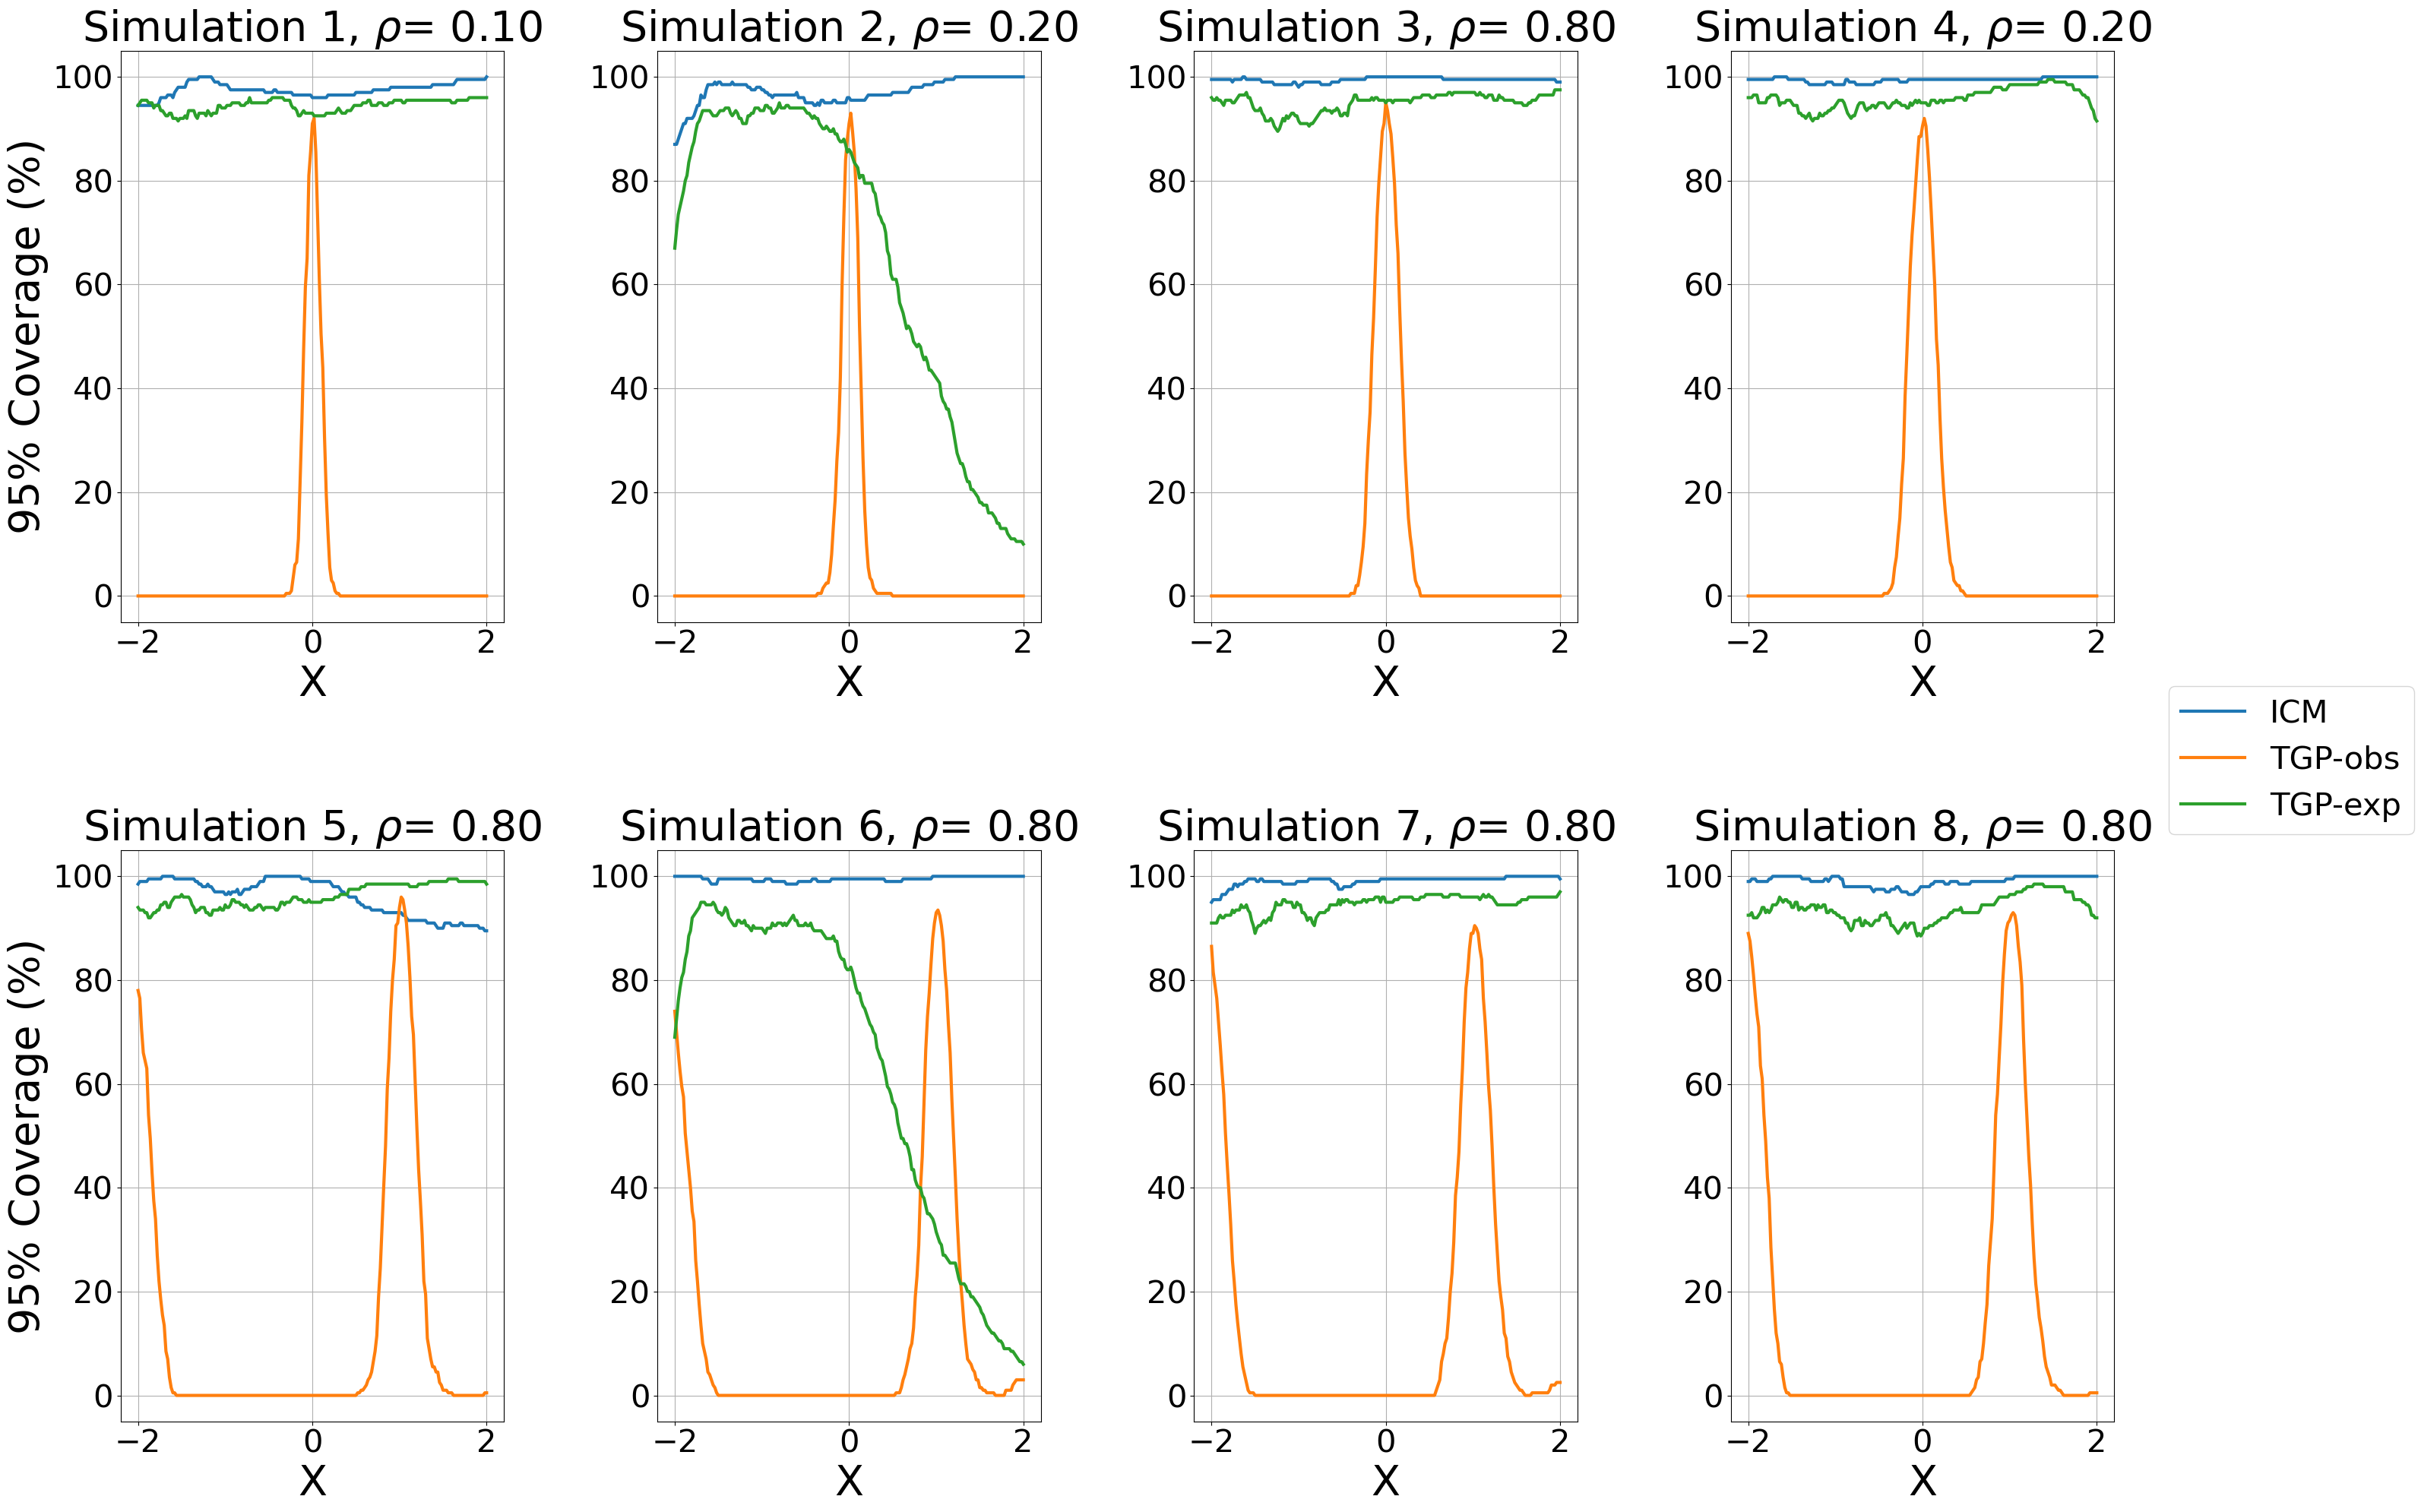

In [222]:
import matplotlib.pyplot as plt
# Create a figure with two subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(32, 20))

axes[0,0].plot(test_data, 100*coverage1_ICM95, linewidth = 3, label = 'ICM')
axes[0,0].plot(test_data, 100*coverage1_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[0,0].plot(test_data, 100*coverage1_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[0,0].set_xlabel('X', fontsize=40)
axes[0,0].set_ylabel('95% Coverage (%)', fontsize=40)
axes[0,0].set_title('Simulation 1, $\\rho$= {:.2f}'.format(best_rho1[0]), fontsize=40, loc='center')
axes[0,0].grid(True)

axes[0,1].plot(test_data, 100*coverage2_ICM95, linewidth = 3, label = 'ICM')
axes[0,1].plot(test_data, 100*coverage2_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[0,1].plot(test_data, 100*coverage2_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[0,1].set_xlabel('X', fontsize=40)
axes[0,1].set_title('Simulation 2, $\\rho$= {:.2f}'.format(best_rho2[0]), fontsize=40, loc='center')
axes[0,1].grid(True)

axes[0,2].plot(test_data, 100*coverage3_ICM95, linewidth = 3, label = 'ICM')
axes[0,2].plot(test_data, 100*coverage3_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[0,2].plot(test_data, 100*coverage3_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[0,2].set_xlabel('X', fontsize=40)
axes[0,2].set_title('Simulation 3, $\\rho$= {:.2f}'.format(best_rho3[0]), fontsize=40, loc='center')
axes[0,2].grid(True)

axes[0,3].plot(test_data, 100*coverage4_ICM95, linewidth = 3, label = 'ICM')
axes[0,3].plot(test_data, 100*coverage4_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[0,3].plot(test_data, 100*coverage4_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[0,3].set_xlabel('X', fontsize=40)
axes[0,3].set_title('Simulation 4, $\\rho$= {:.2f}'.format(best_rho4[0]), fontsize=40, loc='center')
axes[0,3].grid(True)

axes[1,0].plot(test_data, 100*coverage5_ICM95, linewidth = 3, label = 'ICM')
axes[1,0].plot(test_data, 100*coverage5_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[1,0].plot(test_data, 100*coverage5_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[1,0].set_xlabel('X', fontsize=40)
axes[1,0].set_ylabel('95% Coverage (%)', fontsize=40)
axes[1,0].set_title('Simulation 5, $\\rho$= {:.2f}'.format(best_rho5[0]), fontsize=40, loc='center')
axes[1,0].grid(True)

axes[1,1].plot(test_data, 100*coverage6_ICM95, linewidth = 3, label = 'ICM')
axes[1,1].plot(test_data, 100*coverage6_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[1,1].plot(test_data, 100*coverage6_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[1,1].set_xlabel('X', fontsize=40)
axes[1,1].set_title('Simulation 6, $\\rho$= {:.2f}'.format(best_rho6[0]), fontsize=40, loc='center')
axes[1,1].grid(True)

axes[1,2].plot(test_data, 100*coverage7_ICM95, linewidth = 3, label = 'ICM')
axes[1,2].plot(test_data, 100*coverage7_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[1,2].plot(test_data, 100*coverage7_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[1,2].set_xlabel('X', fontsize=40)
axes[1,2].set_title('Simulation 7, $\\rho$= {:.2f}'.format(best_rho7[0]), fontsize=40, loc='center')
axes[1,2].grid(True)

axes[1,3].plot(test_data, 100*coverage8_ICM95, linewidth = 3, label = 'ICM')
axes[1,3].plot(test_data, 100*coverage8_GPobs95, linewidth = 3, label = 'TGP-obs')
axes[1,3].plot(test_data, 100*coverage8_GPexp95, linewidth = 3, label = 'TGP-exp')
axes[1,3].set_xlabel('X', fontsize=40)
axes[1,3].set_title('Simulation 8, $\\rho$= {:.2f}'.format(best_rho8[0]), fontsize=40, loc='center')
axes[1,3].grid(True)

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis='y', labelsize=30)  # Adjust the labelsize as needed
        ax.tick_params(axis='x', labelsize=30)

# Place legend outside the plot
axes[1,3].legend(fontsize=30, loc='lower left', bbox_to_anchor=(1.1, 1))

# Adjust layout
plt.tight_layout()

# Space between row 1 and row 2
plt.subplots_adjust(hspace=0.4, wspace=0.4)

plt.show()


# 90% Coverage Plots

In [138]:

coverage1_ICM90 = sim1_coverage['coverageProbICM90']
coverage1_GPobs90 = sim1_coverage['coverageProbGPobs90']
coverage1_GPexp90 = sim1_coverage['coverageProbGPexp90']

coverage2_ICM90 = sim2_coverage['coverageProbICM90']
coverage2_GPobs90 = sim2_coverage['coverageProbGPobs90']
coverage2_GPexp90 = sim2_coverage['coverageProbGPexp90']

coverage3_ICM90 = sim3_coverage['coverageProbICM90']
coverage3_GPobs90 = sim3_coverage['coverageProbGPobs90']
coverage3_GPexp90 = sim3_coverage['coverageProbGPexp90']

coverage4_ICM90 = sim4_coverage['coverageProbICM90']
coverage4_GPobs90 = sim4_coverage['coverageProbGPobs90']
coverage4_GPexp90 = sim4_coverage['coverageProbGPexp90']

coverage5_ICM90 = sim5_coverage['coverageProbICM90']
coverage5_GPobs90 = sim5_coverage['coverageProbGPobs90']
coverage5_GPexp90 = sim5_coverage['coverageProbGPexp90']

coverage6_ICM90 = sim6_coverage['coverageProbICM90']
coverage6_GPobs90 = sim6_coverage['coverageProbGPobs90']
coverage6_GPexp90 = sim6_coverage['coverageProbGPexp90']

coverage7_ICM90 = sim7_coverage['coverageProbICM90']
coverage7_GPobs90 = sim7_coverage['coverageProbGPobs90']
coverage7_GPexp90 = sim7_coverage['coverageProbGPexp90']

coverage8_ICM90 = sim8_coverage['coverageProbICM90']
coverage8_GPobs90 = sim8_coverage['coverageProbGPobs90']
coverage8_GPexp90 = sim8_coverage['coverageProbGPexp90']



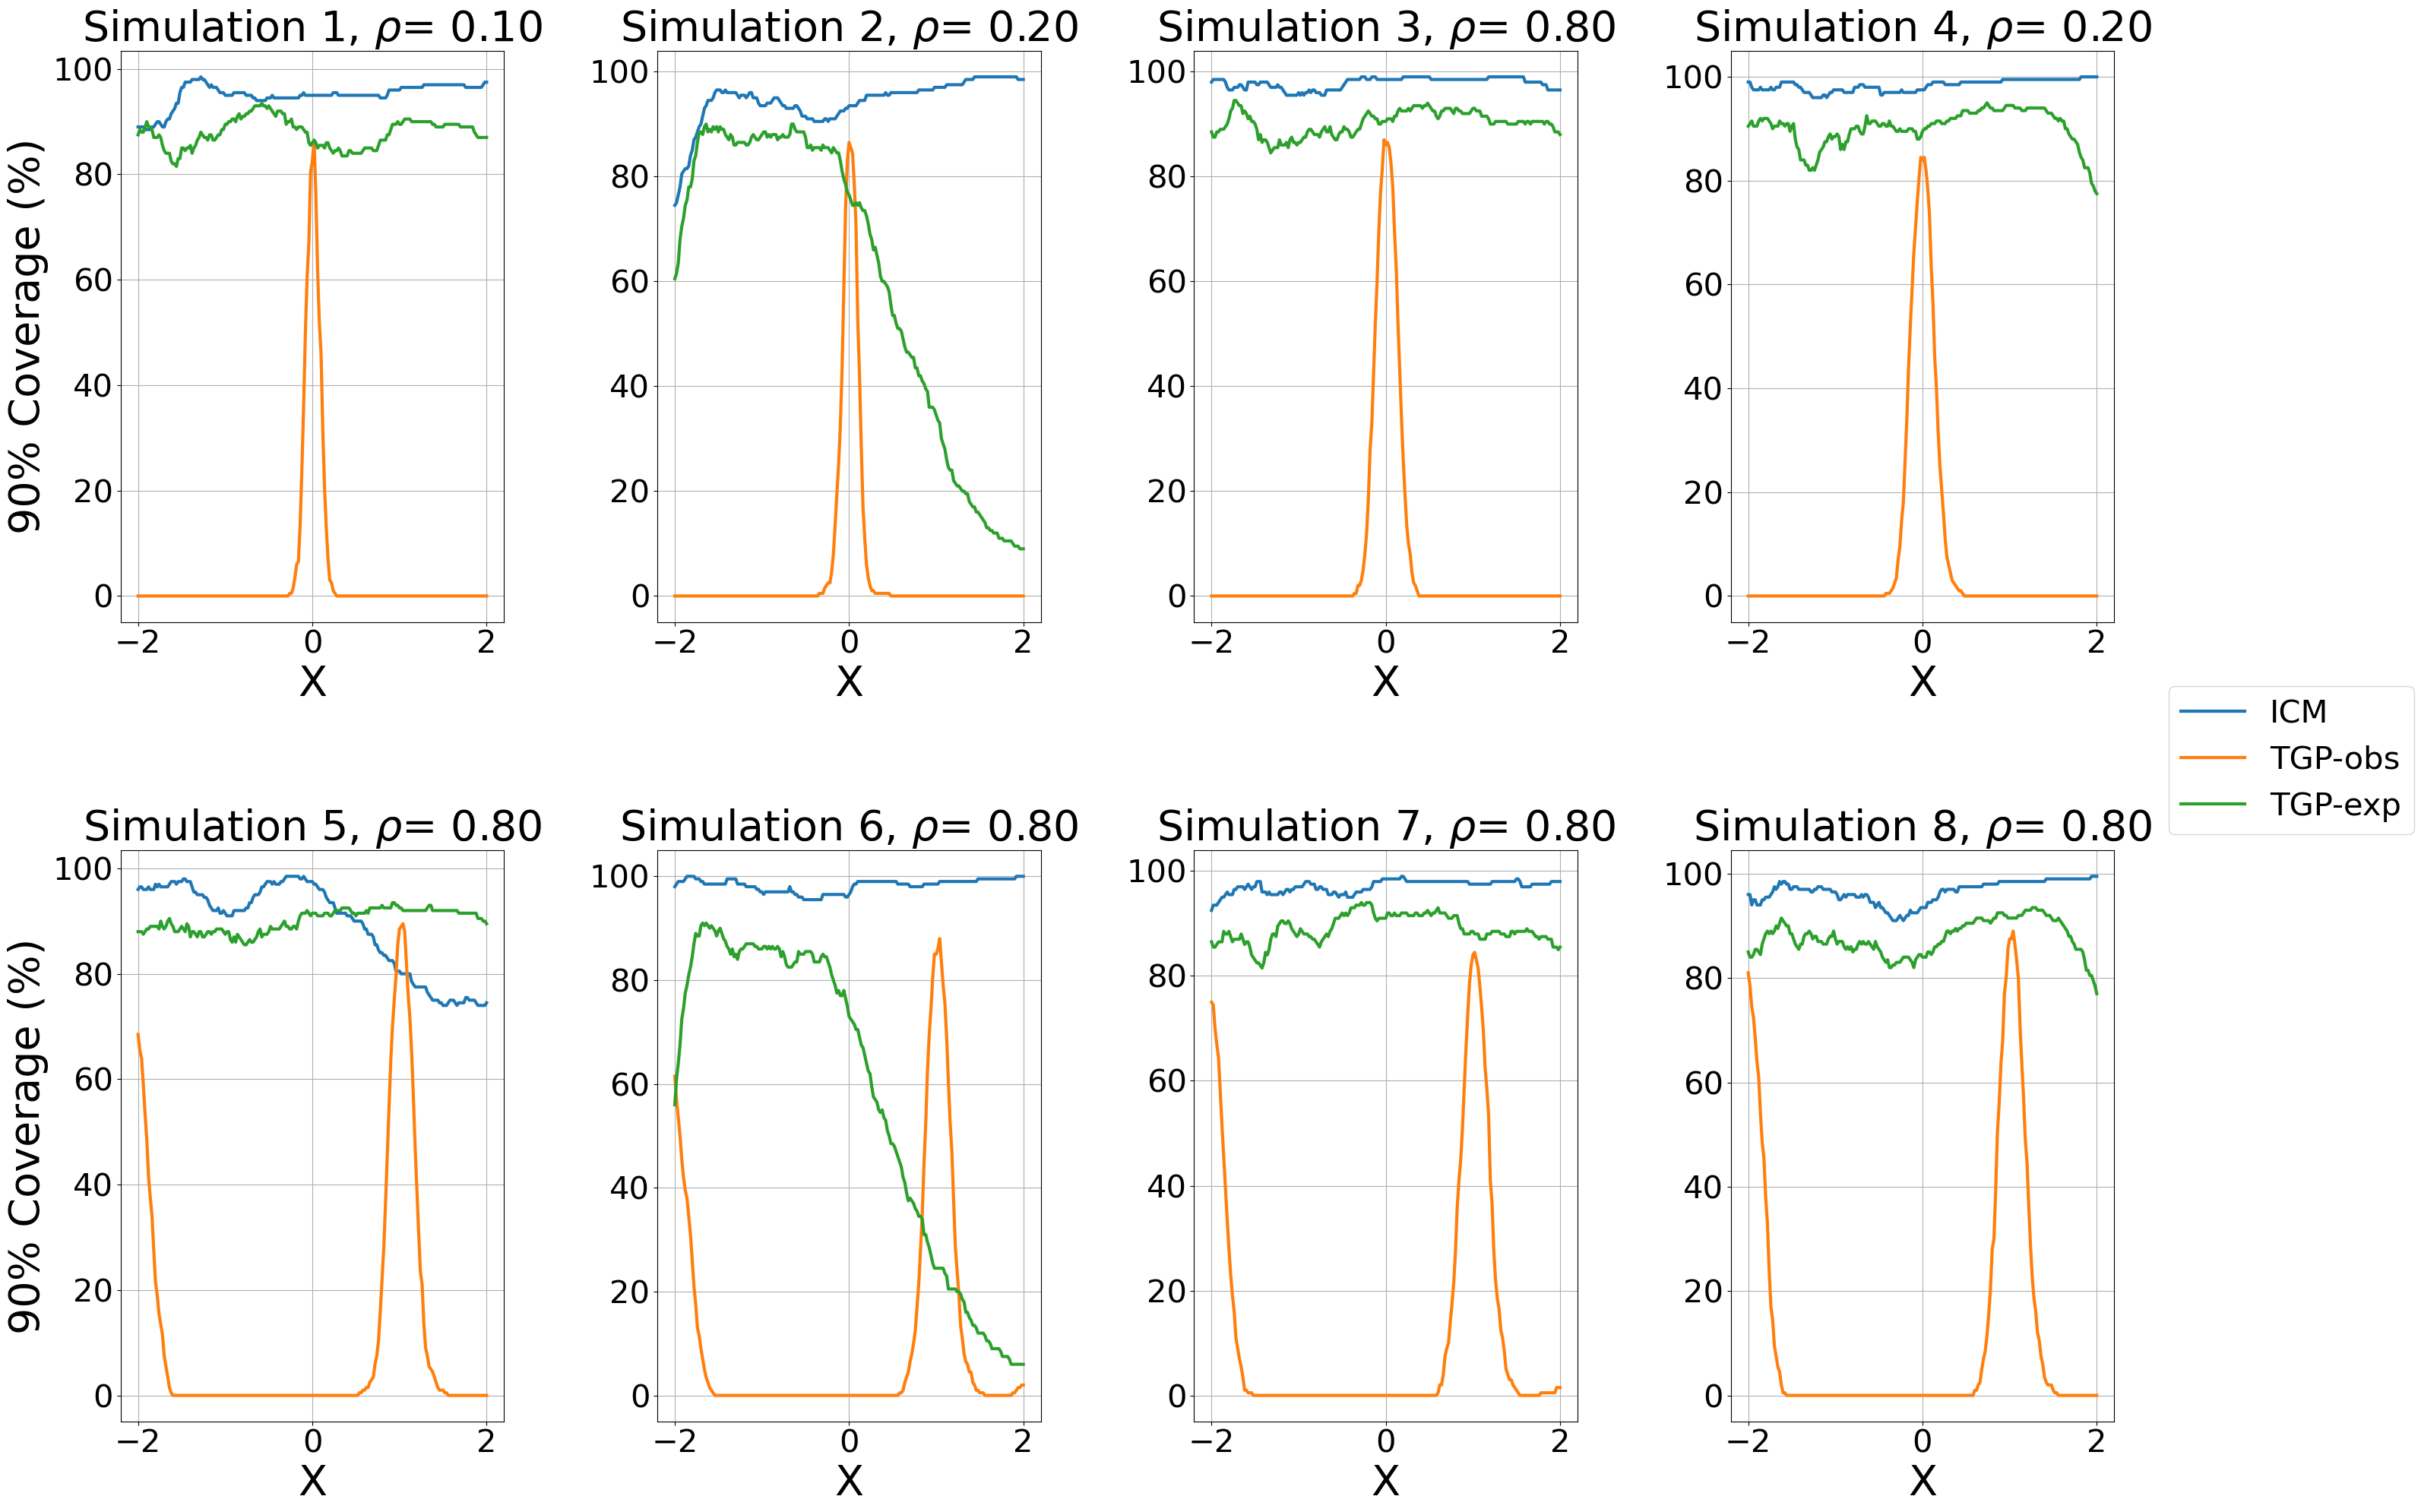

In [223]:
# Create a figure with two subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(32, 20))

axes[0,0].plot(test_data, 100*coverage1_ICM90, linewidth = 3, label = 'ICM')
axes[0,0].plot(test_data, 100*coverage1_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[0,0].plot(test_data, 100*coverage1_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[0,0].set_xlabel('X', fontsize=40)
axes[0,0].set_ylabel('90% Coverage (%)', fontsize=40)
axes[0,0].set_title('Simulation 1, $\\rho$= {:.2f}'.format(best_rho1[0]), fontsize=40, loc='center')
axes[0,0].grid(True)

axes[0,1].plot(test_data, 100*coverage2_ICM90, linewidth = 3, label = 'ICM')
axes[0,1].plot(test_data, 100*coverage2_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[0,1].plot(test_data, 100*coverage2_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[0,1].set_xlabel('X', fontsize=40)
axes[0,1].set_title('Simulation 2, $\\rho$= {:.2f}'.format(best_rho2[0]), fontsize=40,loc='center')
axes[0,1].grid(True)

axes[0,2].plot(test_data, 100*coverage3_ICM90, linewidth = 3, label = 'ICM')
axes[0,2].plot(test_data, 100*coverage3_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[0,2].plot(test_data, 100*coverage3_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[0,2].set_xlabel('X', fontsize=40)
axes[0,2].set_title('Simulation 3, $\\rho$= {:.2f}'.format(best_rho3[0]), fontsize=40, loc='center')
axes[0,2].grid(True)

axes[0,3].plot(test_data, 100*coverage4_ICM90, linewidth = 3, label = 'ICM')
axes[0,3].plot(test_data, 100*coverage4_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[0,3].plot(test_data, 100*coverage4_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[0,3].set_xlabel('X', fontsize=40)
axes[0,3].set_title('Simulation 4, $\\rho$= {:.2f}'.format(best_rho4[0]), fontsize=40, loc='center')
axes[0,3].grid(True)

axes[1,0].plot(test_data, 100*coverage5_ICM90, linewidth = 3, label = 'ICM')
axes[1,0].plot(test_data, 100*coverage5_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[1,0].plot(test_data, 100*coverage5_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[1,0].set_xlabel('X', fontsize=40)
axes[1,0].set_ylabel('90% Coverage (%)', fontsize=40)
axes[1,0].set_title('Simulation 5, $\\rho$= {:.2f}'.format(best_rho5[0]), fontsize=40, loc='center')
axes[1,0].grid(True)

axes[1,1].plot(test_data, 100*coverage6_ICM90, linewidth = 3, label = 'ICM')
axes[1,1].plot(test_data, 100*coverage6_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[1,1].plot(test_data, 100*coverage6_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[1,1].set_xlabel('X', fontsize=40)
axes[1,1].set_title('Simulation 6, $\\rho$= {:.2f}'.format(best_rho6[0]), fontsize=40, loc='center')
axes[1,1].grid(True)

axes[1,2].plot(test_data, 100*coverage7_ICM90, linewidth = 3, label = 'ICM')
axes[1,2].plot(test_data, 100*coverage7_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[1,2].plot(test_data, 100*coverage7_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[1,2].set_xlabel('X', fontsize=40)
axes[1,2].set_title('Simulation 7, $\\rho$= {:.2f}'.format(best_rho7[0]), fontsize=40, loc='center')
axes[1,2].grid(True)

axes[1,3].plot(test_data, 100*coverage8_ICM90, linewidth = 3, label = 'ICM')
axes[1,3].plot(test_data, 100*coverage8_GPobs90, linewidth = 3, label = 'TGP-obs')
axes[1,3].plot(test_data, 100*coverage8_GPexp90, linewidth = 3, label = 'TGP-exp')
axes[1,3].set_xlabel('X', fontsize=40)
axes[1,3].set_title('Simulation 8, $\\rho$= {:.2f}'.format(best_rho8[0]), fontsize=40, loc='center')
axes[1,3].grid(True)

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis='y', labelsize=30)  # Adjust the labelsize as needed
        ax.tick_params(axis='x', labelsize=30)

# Place legend outside the plot
axes[1,3].legend(fontsize=30, loc='lower left', bbox_to_anchor=(1.1, 1))

# Adjust layout
plt.tight_layout()

# Space between row 1 and row 2
plt.subplots_adjust(hspace=0.4, wspace=0.4)

plt.show()


# 95% CI Length Plots

In [224]:
sim1_length = pd.read_csv('/Simulation1/sim1_length.csv')
sim2_length = pd.read_csv('/Simulation2/sim2_length.csv')
sim3_length = pd.read_csv('/Simulation3/sim3_length.csv')
sim4_length = pd.read_csv('/Simulation4/sim4_length.csv')
sim5_length = pd.read_csv('/Simulation5/sim5_length.csv')
sim6_length = pd.read_csv('/Simulation6/sim6_length.csv')
sim7_length = pd.read_csv('/Simulation7/sim7_length.csv')
sim8_length = pd.read_csv('/Simulation8/sim8_length.csv')


In [225]:
length1_ICM95 = sim1_length['length_ICM95']
length1_GPobs95 = sim1_length['length_GPobs95']
length1_GPexp95 = sim1_length['length_GPexp95']

length2_ICM95 = sim2_length['length_ICM95']
length2_GPobs95 = sim2_length['length_GPobs95']
length2_GPexp95 = sim2_length['length_GPexp95']

length3_ICM95 = sim3_length['length_ICM95']
length3_GPobs95 = sim3_length['length_GPobs95']
length3_GPexp95 = sim3_length['length_GPexp95']

length4_ICM95 = sim4_length['length_ICM95']
length4_GPobs95 = sim4_length['length_GPobs95']
length4_GPexp95 = sim4_length['length_GPexp95']

length5_ICM95 = sim5_length['length_ICM95']
length5_GPobs95 = sim5_length['length_GPobs95']
length5_GPexp95 = sim5_length['length_GPexp95']

length6_ICM95 = sim6_length['length_ICM95']
length6_GPobs95 = sim6_length['length_GPobs95']
length6_GPexp95 = sim6_length['length_GPexp95']

length7_ICM95 = sim7_length['length_ICM95']
length7_GPobs95 = sim7_length['length_GPobs95']
length7_GPexp95 = sim7_length['length_GPexp95']

length8_ICM95 = sim8_length['length_ICM95']
length8_GPobs95 = sim8_length['length_GPobs95']
length8_GPexp95 = sim8_length['length_GPexp95']

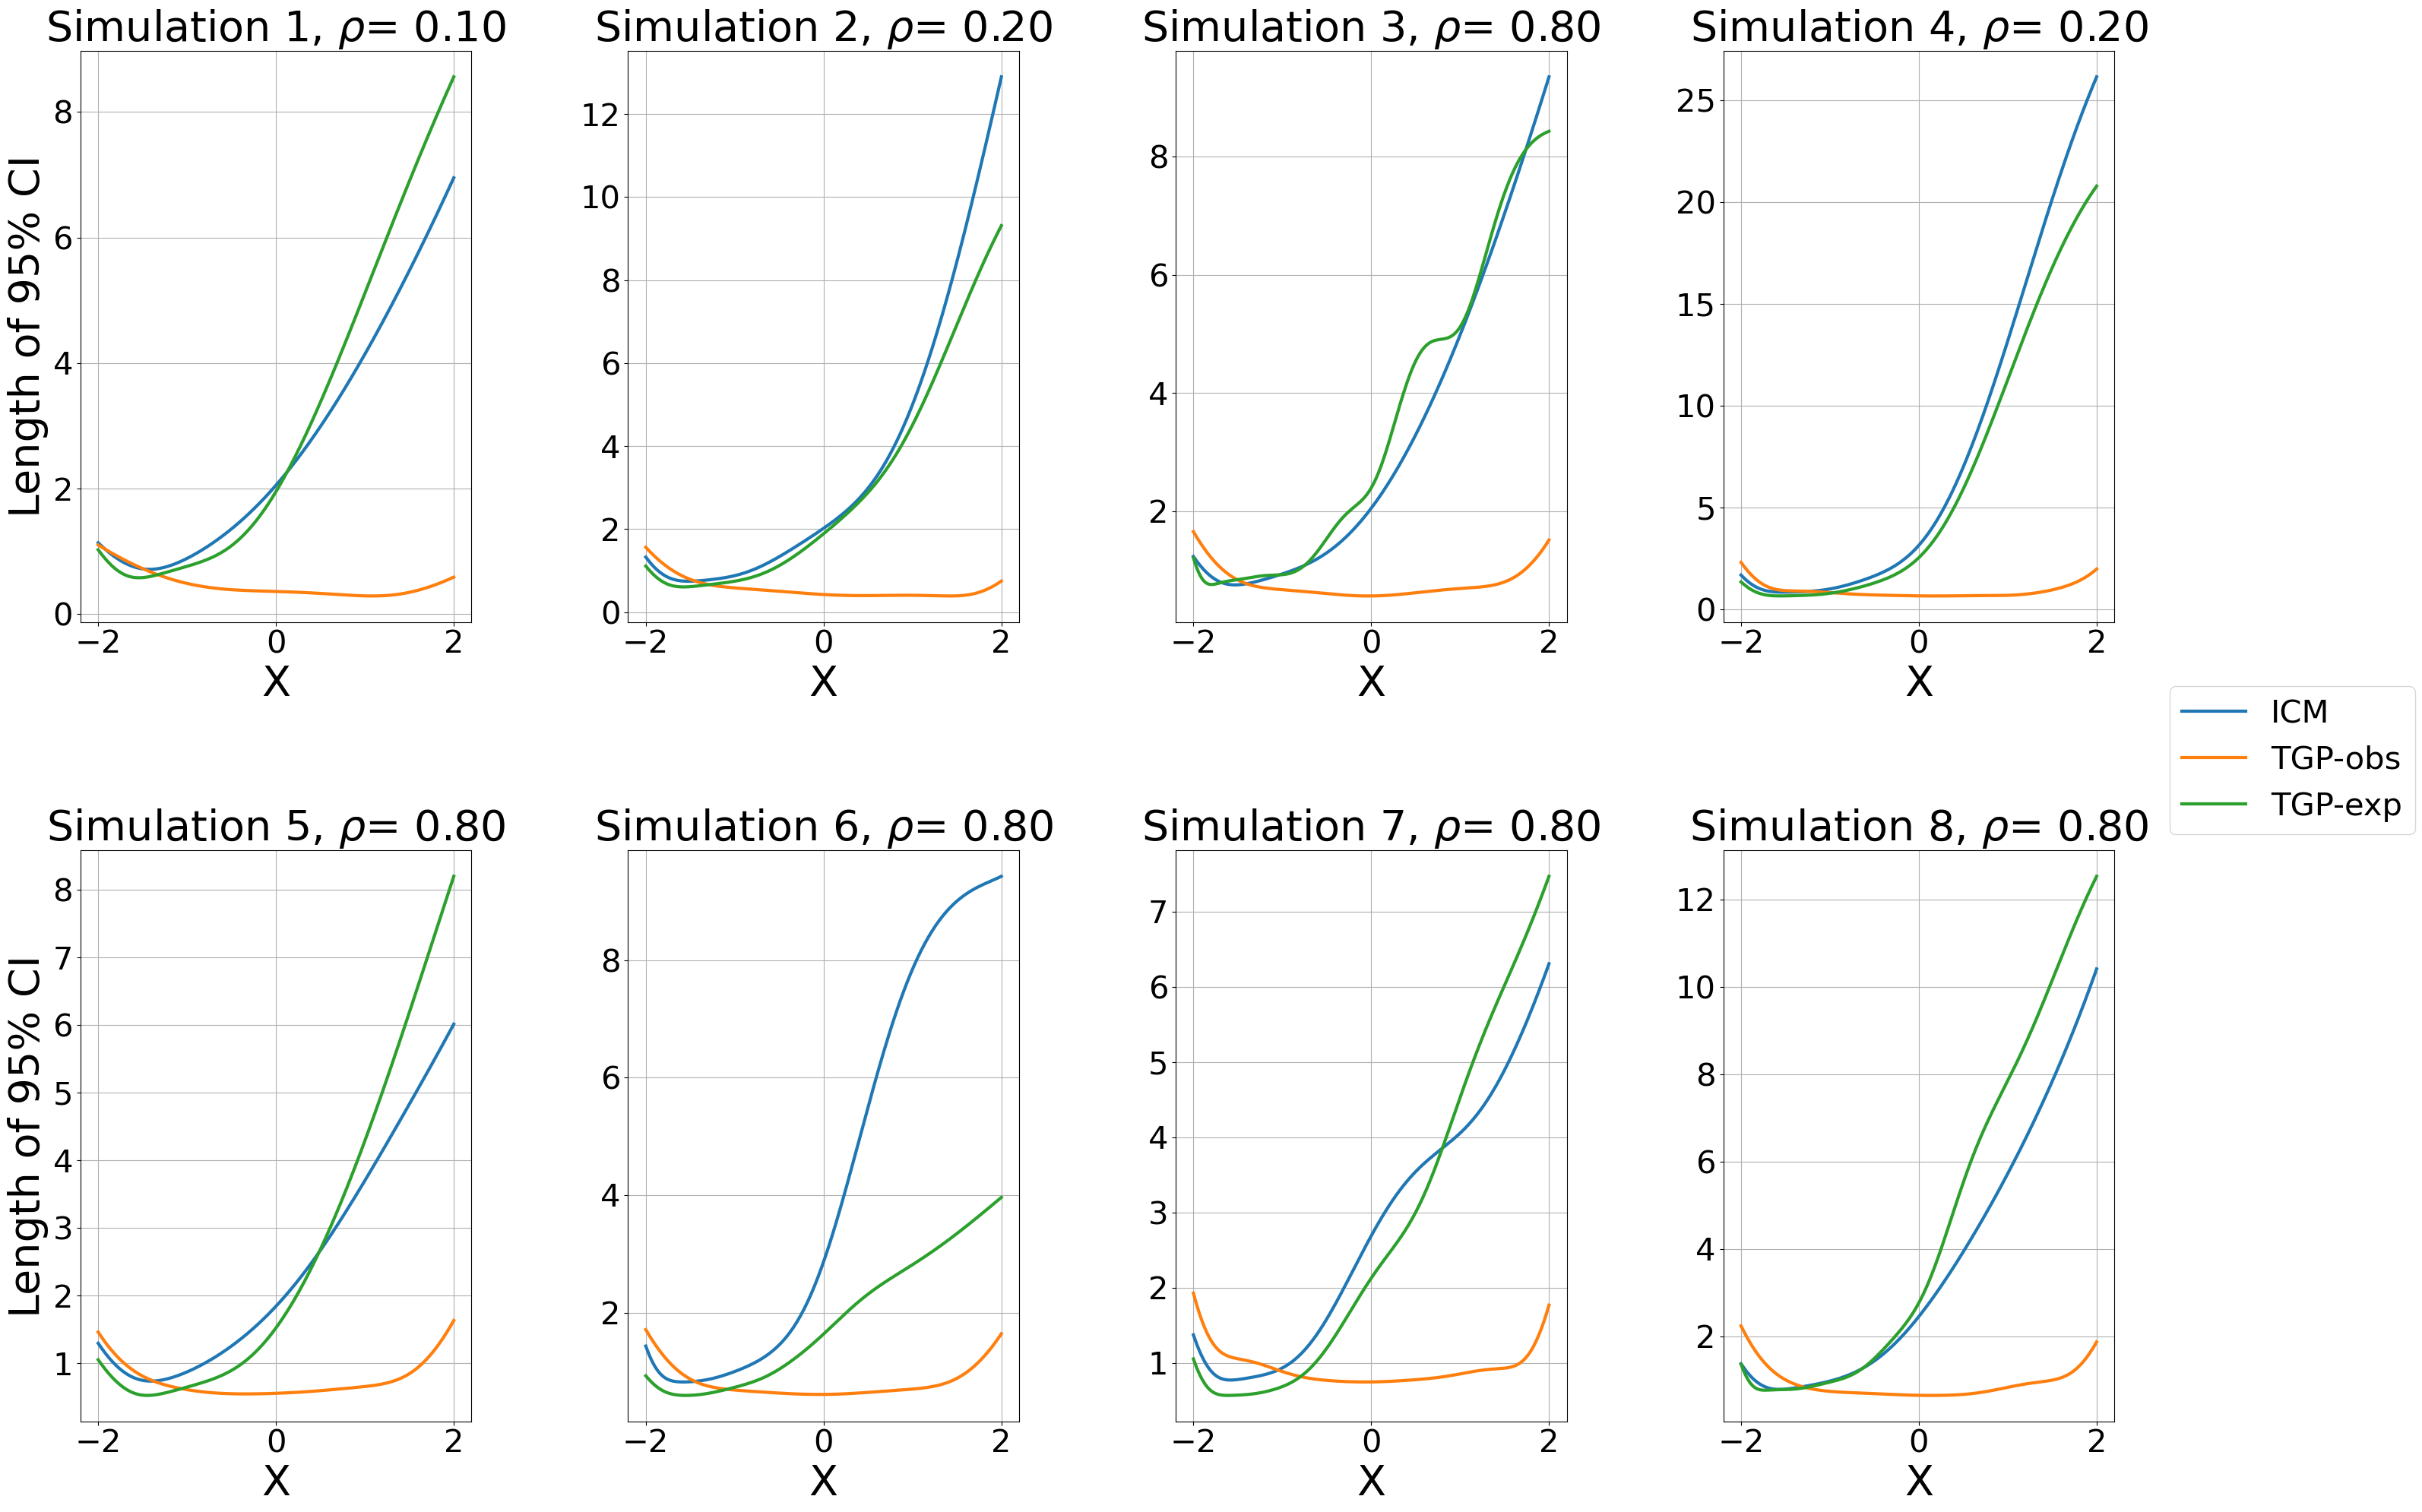

In [227]:
import matplotlib.pyplot as plt
# Create a figure with two subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(32, 20))

axes[0,0].plot(test_data, length1_ICM95, linewidth = 3, label = 'ICM')
axes[0,0].plot(test_data, length1_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[0,0].plot(test_data, length1_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[0,0].set_xlabel('X', fontsize=40)
axes[0,0].set_ylabel('Length of 95% CI', fontsize=40)
axes[0,0].set_title('Simulation 1, $\\rho$= {:.2f}'.format(best_rho1[0]), fontsize=40, loc='center')
axes[0,0].grid(True)

axes[0,1].plot(test_data, length2_ICM95, linewidth = 3, label = 'ICM')
axes[0,1].plot(test_data, length2_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[0,1].plot(test_data, length2_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[0,1].set_xlabel('X', fontsize=40)
axes[0,1].set_title('Simulation 2, $\\rho$= {:.2f}'.format(best_rho2[0]), fontsize=40, loc='center')
axes[0,1].grid(True)

axes[0,2].plot(test_data, length3_ICM95, linewidth = 3, label = 'ICM')
axes[0,2].plot(test_data, length3_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[0,2].plot(test_data, length3_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[0,2].set_xlabel('X', fontsize=40)
axes[0,2].set_title('Simulation 3, $\\rho$= {:.2f}'.format(best_rho3[0]), fontsize=40, loc='center')
axes[0,2].grid(True)

axes[0,3].plot(test_data, length4_ICM95, linewidth = 3, label = 'ICM')
axes[0,3].plot(test_data, length4_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[0,3].plot(test_data, length4_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[0,3].set_xlabel('X', fontsize=40)
axes[0,3].set_title('Simulation 4, $\\rho$= {:.2f}'.format(best_rho4[0]), fontsize=40, loc='center')
axes[0,3].grid(True)

axes[1,0].plot(test_data, length5_ICM95, linewidth = 3, label = 'ICM')
axes[1,0].plot(test_data, length5_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[1,0].plot(test_data, length5_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[1,0].set_xlabel('X', fontsize=40)
axes[1,0].set_ylabel('Length of 95% CI', fontsize=40)
axes[1,0].set_title('Simulation 5, $\\rho$= {:.2f}'.format(best_rho5[0]), fontsize=40, loc='center')
axes[1,0].grid(True)

axes[1,1].plot(test_data, length6_ICM95, linewidth = 3, label = 'ICM')
axes[1,1].plot(test_data, length6_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[1,1].plot(test_data, length6_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[1,1].set_xlabel('X', fontsize=40)
axes[1,1].set_title('Simulation 6, $\\rho$= {:.2f}'.format(best_rho6[0]), fontsize=40, loc='center')
axes[1,1].grid(True)

axes[1,2].plot(test_data, length7_ICM95, linewidth = 3, label = 'ICM')
axes[1,2].plot(test_data, length7_GPobs95, linewidth = 3, label = 'GP T-learner - obs')
axes[1,2].plot(test_data, length7_GPexp95, linewidth = 3, label = 'GP T-learner - exp')
axes[1,2].set_xlabel('X', fontsize=40)
axes[1,2].set_title('Simulation 7, $\\rho$= {:.2f}'.format(best_rho7[0]), fontsize=40, loc='center')
axes[1,2].grid(True)

axes[1,3].plot(test_data, length8_ICM95, linewidth = 3, label = 'ICM')
axes[1,3].plot(test_data, length8_GPobs95, linewidth = 3, label = 'TGP-obs')
axes[1,3].plot(test_data, length8_GPexp95, linewidth = 3, label = 'TGP-exp')
axes[1,3].set_xlabel('X', fontsize=40)
axes[1,3].set_title('Simulation 8, $\\rho$= {:.2f}'.format(best_rho8[0]), fontsize=40, loc='center')
axes[1,3].grid(True)

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis='y', labelsize=30)  # Adjust the labelsize as needed
        ax.tick_params(axis='x', labelsize=30)

# Place legend outside the plot
axes[1,3].legend(fontsize=30, loc='lower left', bbox_to_anchor=(1.1, 1))

# Adjust layout
plt.tight_layout()

# Space between row 1 and row 2
plt.subplots_adjust(hspace=0.4, wspace=0.4)

plt.show()


In [228]:
length1_ICM90 = sim1_length['length_ICM90']
length1_GPobs90 = sim1_length['length_GPobs90']
length1_GPexp90 = sim1_length['length_GPexp90']

length2_ICM90 = sim2_length['length_ICM90']
length2_GPobs90 = sim2_length['length_GPobs90']
length2_GPexp90 = sim2_length['length_GPexp90']

length3_ICM90 = sim3_length['length_ICM90']
length3_GPobs90 = sim3_length['length_GPobs90']
length3_GPexp90 = sim3_length['length_GPexp90']

length4_ICM90 = sim4_length['length_ICM90']
length4_GPobs90 = sim4_length['length_GPobs90']
length4_GPexp90 = sim4_length['length_GPexp90']

length5_ICM90 = sim5_length['length_ICM90']
length5_GPobs90 = sim5_length['length_GPobs90']
length5_GPexp90 = sim5_length['length_GPexp90']

length6_ICM90 = sim6_length['length_ICM90']
length6_GPobs90 = sim6_length['length_GPobs90']
length6_GPexp90 = sim6_length['length_GPexp90']

length7_ICM90 = sim7_length['length_ICM90']
length7_GPobs90 = sim7_length['length_GPobs90']
length7_GPexp90 = sim7_length['length_GPexp90']

length8_ICM90 = sim8_length['length_ICM90']
length8_GPobs90 = sim8_length['length_GPobs90']
length8_GPexp90 = sim8_length['length_GPexp90']

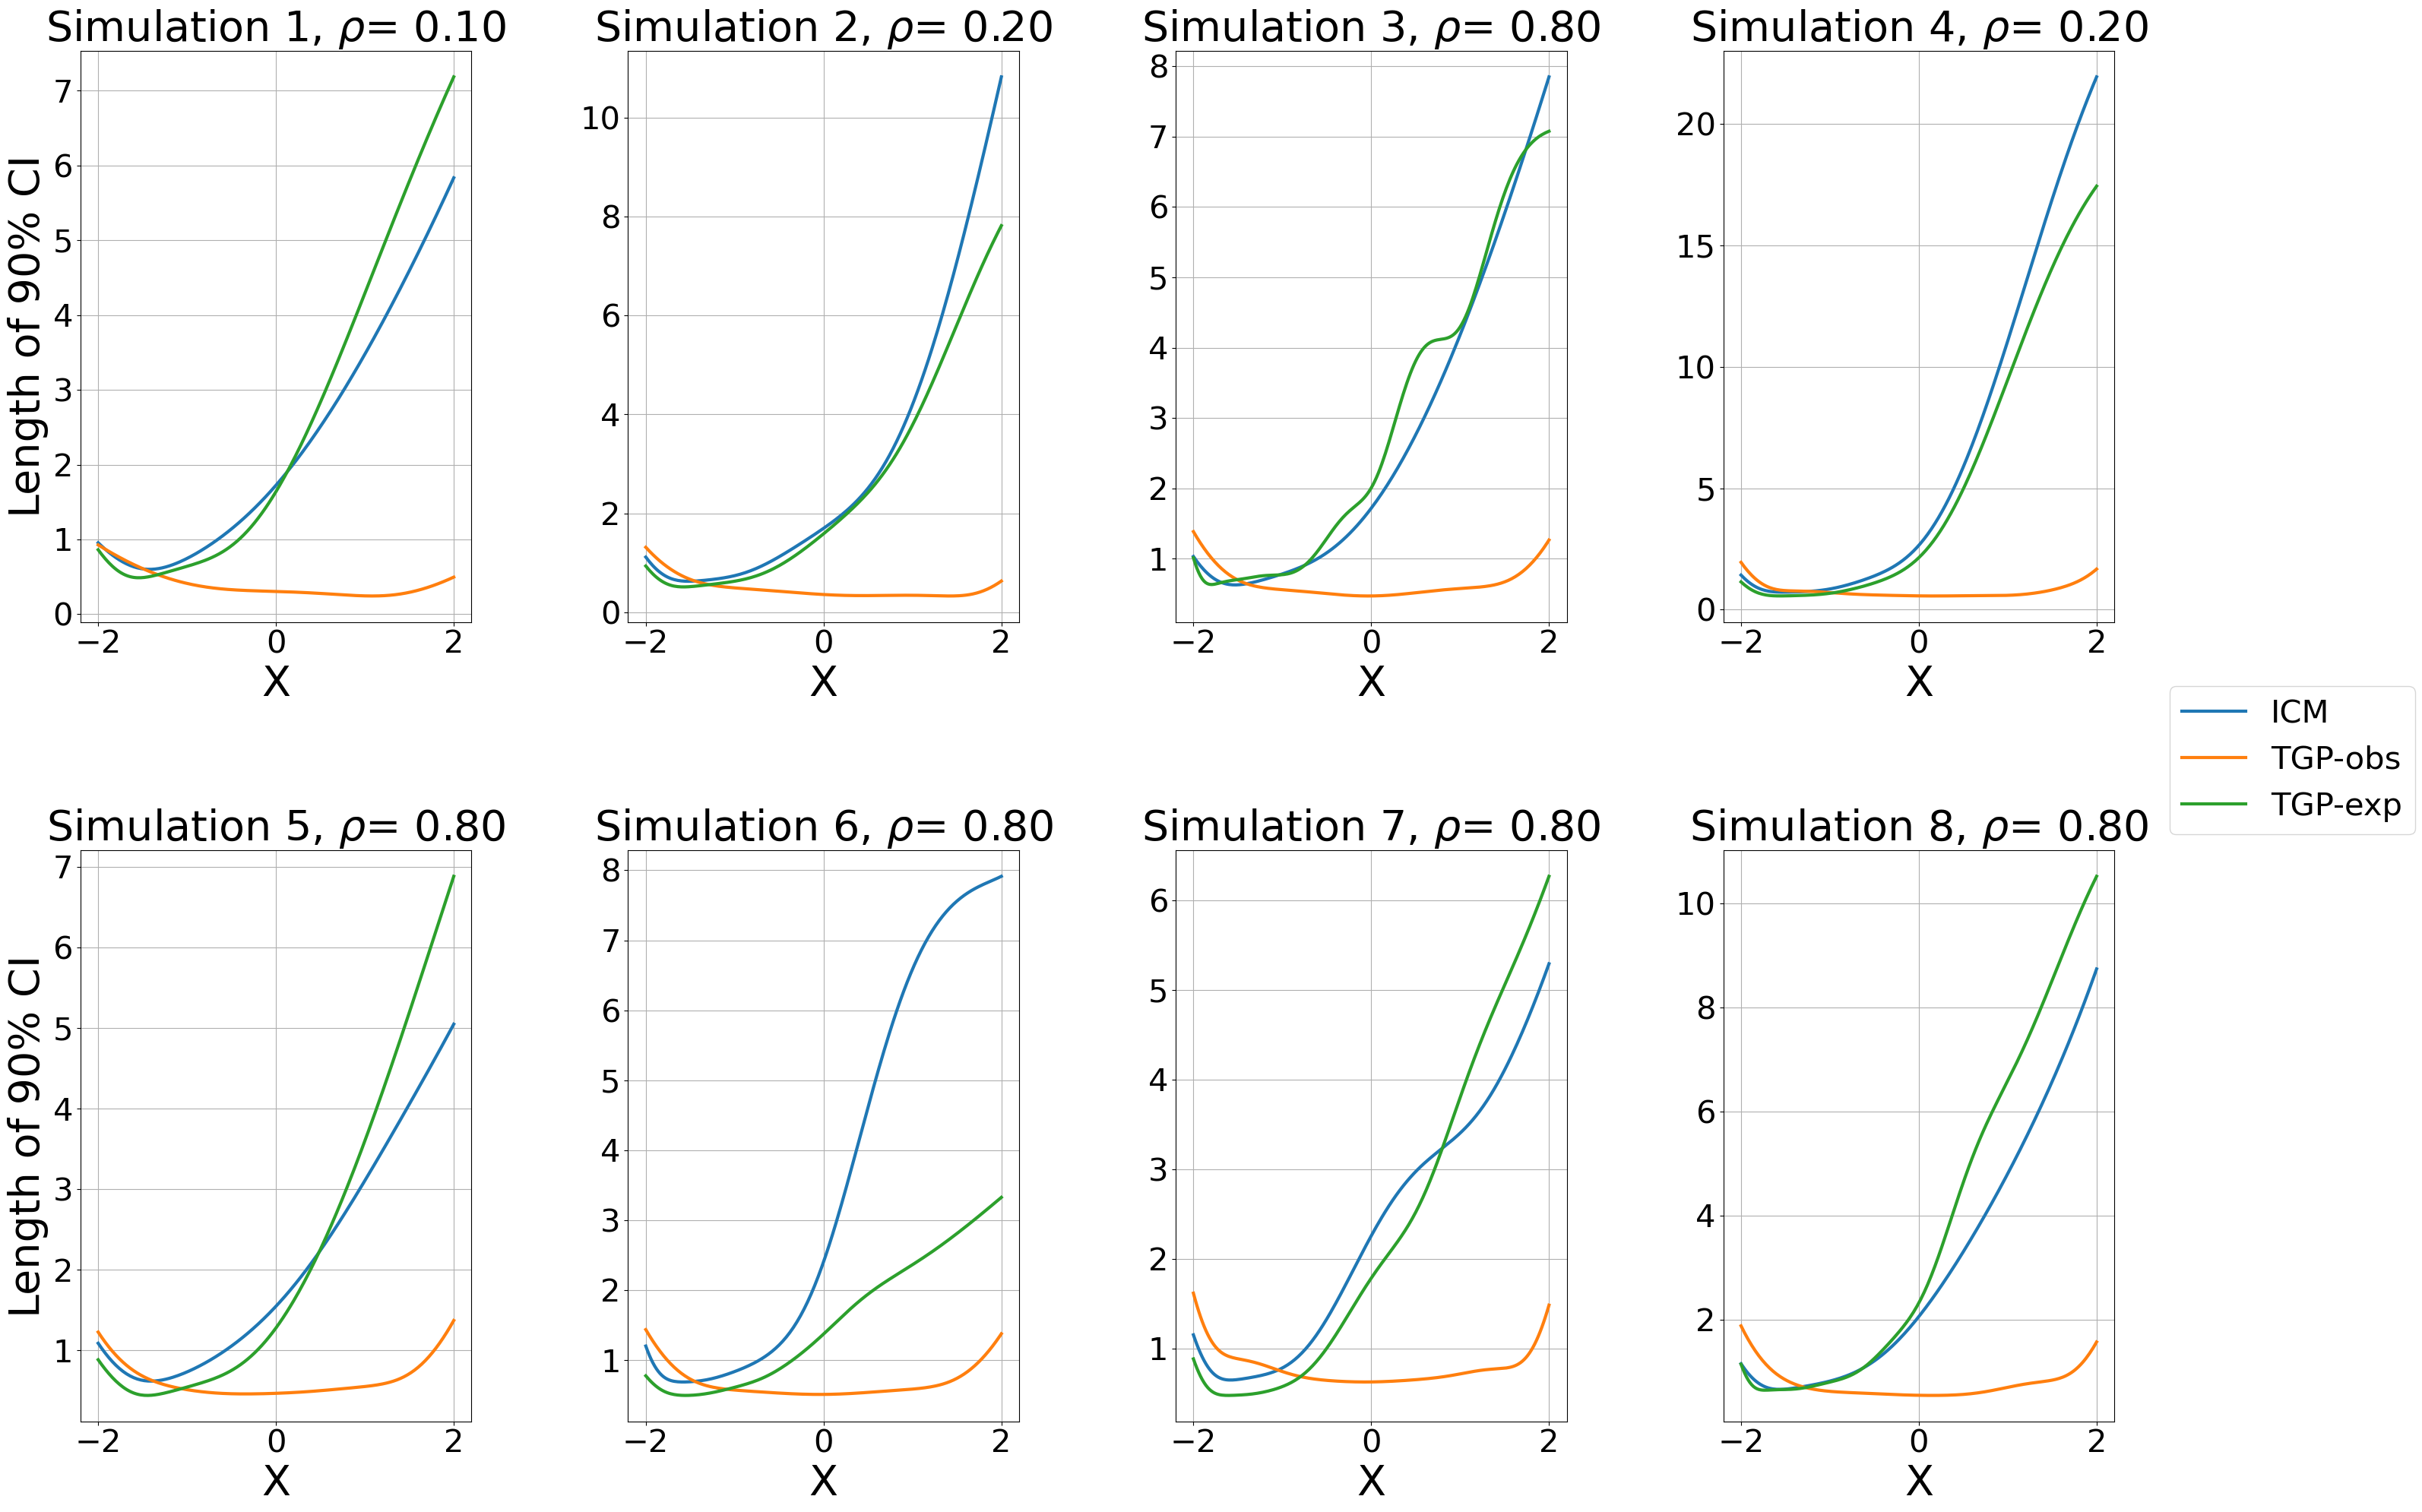

In [229]:
import matplotlib.pyplot as plt
# Create a figure with two subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(32, 20))

axes[0,0].plot(test_data, length1_ICM90, linewidth = 3, label = 'ICM')
axes[0,0].plot(test_data, length1_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[0,0].plot(test_data, length1_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[0,0].set_xlabel('X', fontsize=40)
axes[0,0].set_ylabel('Length of 90% CI', fontsize=40)
axes[0,0].set_title('Simulation 1, $\\rho$= {:.2f}'.format(best_rho1[0]), fontsize=40, loc='center')
axes[0,0].grid(True)

axes[0,1].plot(test_data, length2_ICM90, linewidth = 3, label = 'ICM')
axes[0,1].plot(test_data, length2_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[0,1].plot(test_data, length2_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[0,1].set_xlabel('X', fontsize=40)
axes[0,1].set_title('Simulation 2, $\\rho$= {:.2f}'.format(best_rho2[0]), fontsize=40, loc='center')
axes[0,1].grid(True)

axes[0,2].plot(test_data, length3_ICM90, linewidth = 3, label = 'ICM')
axes[0,2].plot(test_data, length3_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[0,2].plot(test_data, length3_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[0,2].set_xlabel('X', fontsize=40)
axes[0,2].set_title('Simulation 3, $\\rho$= {:.2f}'.format(best_rho3[0]), fontsize=40, loc='center')
axes[0,2].grid(True)

axes[0,3].plot(test_data, length4_ICM90, linewidth = 3, label = 'ICM')
axes[0,3].plot(test_data, length4_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[0,3].plot(test_data, length4_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[0,3].set_xlabel('X', fontsize=40)
axes[0,3].set_title('Simulation 4, $\\rho$= {:.2f}'.format(best_rho4[0]), fontsize=40, loc='center')
axes[0,3].grid(True)

axes[1,0].plot(test_data, length5_ICM90, linewidth = 3, label = 'ICM')
axes[1,0].plot(test_data, length5_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[1,0].plot(test_data, length5_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[1,0].set_xlabel('X', fontsize=40)
axes[1,0].set_ylabel('Length of 90% CI', fontsize=40)
axes[1,0].set_title('Simulation 5, $\\rho$= {:.2f}'.format(best_rho5[0]), fontsize=40, loc='center')
axes[1,0].grid(True)

axes[1,1].plot(test_data, length6_ICM90, linewidth = 3, label = 'ICM')
axes[1,1].plot(test_data, length6_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[1,1].plot(test_data, length6_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[1,1].set_xlabel('X', fontsize=40)
axes[1,1].set_title('Simulation 6, $\\rho$= {:.2f}'.format(best_rho6[0]), fontsize=40, loc='center')
axes[1,1].grid(True)

axes[1,2].plot(test_data, length7_ICM90, linewidth = 3, label = 'ICM')
axes[1,2].plot(test_data, length7_GPobs90, linewidth = 3, label = 'GP T-learner - obs')
axes[1,2].plot(test_data, length7_GPexp90, linewidth = 3, label = 'GP T-learner - exp')
axes[1,2].set_xlabel('X', fontsize=40)
axes[1,2].set_title('Simulation 7, $\\rho$= {:.2f}'.format(best_rho7[0]), fontsize=40, loc='center')
axes[1,2].grid(True)

axes[1,3].plot(test_data, length8_ICM90, linewidth = 3, label = 'ICM')
axes[1,3].plot(test_data, length8_GPobs90, linewidth = 3, label = 'TGP-obs')
axes[1,3].plot(test_data, length8_GPexp90, linewidth = 3, label = 'TGP-exp')
axes[1,3].set_xlabel('X', fontsize=40)
axes[1,3].set_title('Simulation 8, $\\rho$= {:.2f}'.format(best_rho8[0]), fontsize=40, loc='center')
axes[1,3].grid(True)

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis='y', labelsize=30)  # Adjust the labelsize as needed
        ax.tick_params(axis='x', labelsize=30)

# Place legend outside the plot
axes[1,3].legend(fontsize=30, loc='lower left', bbox_to_anchor=(1.1, 1))

# Adjust layout
plt.tight_layout()

# Space between row 1 and row 2
plt.subplots_adjust(hspace=0.4, wspace=0.4)

plt.show()


# Model fit Plots

In [362]:
import numpy as np
from sklearn.metrics import mean_squared_error
import GPy

['/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS', '/Users/evangelosdimitriou/anaconda3/lib/python310.zip', '/Users/evangelosdimitriou/anaconda3/lib/python3.10', '/Users/evangelosdimitriou/anaconda3/lib/python3.10/lib-dynload', '', '/Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages', '/Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/PyQt5_sip-12.11.0-py3.10-macosx-10.9-x86_64.egg', '/Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/aeosa', '/Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/mpmath-1.2.1-py3.10.egg', '/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/', '/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/', '/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/', '/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-T

In [363]:
from functions.data_simulation import data_simulation1
from functions.data_simulation import data_simulation2
from functions.data_simulation import data_simulation3
from functions.data_simulation import data_simulation4
from functions.data_simulation import data_simulation5
from functions.data_simulation import data_simulation6
from functions.data_simulation import data_simulation7
from functions.data_simulation import data_simulation8
from functions.model_training import ICM

In [364]:
seed_value= 1234
# 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
import os
os.environ['PYTHONHASHSEED']=str(seed_value)
# 2. Set the `python` built-in pseudo-random generator at a fixed value
import random
random.seed(seed_value)
# 3. Set the `numpy` pseudo-random generator at a fixed value
import numpy as np 
np.random.seed(seed_value)
data_exp1, data_obs1 = data_simulation1(1000, beta0=-3.0, beta1=-3.0)

In [365]:
seed_value= 1234
# 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
import os
os.environ['PYTHONHASHSEED']=str(seed_value)
# 2. Set the `python` built-in pseudo-random generator at a fixed value
import random
random.seed(seed_value)
# 3. Set the `numpy` pseudo-random generator at a fixed value
import numpy as np 
np.random.seed(seed_value)
data_exp2, data_obs2 = data_simulation2(1000, beta0=-3.0, beta1=-3.0)

In [366]:
seed_value= 1234
# 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
import os
os.environ['PYTHONHASHSEED']=str(seed_value)
# 2. Set the `python` built-in pseudo-random generator at a fixed value
import random
random.seed(seed_value)
# 3. Set the `numpy` pseudo-random generator at a fixed value
import numpy as np 
np.random.seed(seed_value)
data_exp3, data_obs3 = data_simulation3(1000, beta0=-3.0, beta1=-3.0)

In [367]:
seed_value= 1234
# 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
import os
os.environ['PYTHONHASHSEED']=str(seed_value)
# 2. Set the `python` built-in pseudo-random generator at a fixed value
import random
random.seed(seed_value)
# 3. Set the `numpy` pseudo-random generator at a fixed value
import numpy as np 
np.random.seed(seed_value)
data_exp4, data_obs4 = data_simulation4(1000, beta0=-3.0, beta1=-3.0)

In [368]:
seed_value= 1234
# 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
import os
os.environ['PYTHONHASHSEED']=str(seed_value)
# 2. Set the `python` built-in pseudo-random generator at a fixed value
import random
random.seed(seed_value)
# 3. Set the `numpy` pseudo-random generator at a fixed value
import numpy as np 
np.random.seed(seed_value)
data_exp5, data_obs5 = data_simulation5(1000, beta0=-3.0, beta1=-3.0)

In [369]:
seed_value= 1234
# 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
import os
os.environ['PYTHONHASHSEED']=str(seed_value)
# 2. Set the `python` built-in pseudo-random generator at a fixed value
import random
random.seed(seed_value)
# 3. Set the `numpy` pseudo-random generator at a fixed value
import numpy as np 
np.random.seed(seed_value)
data_exp6, data_obs6 = data_simulation6(1000, beta0=-3.0, beta1=-3.0)

In [370]:
seed_value= 1234
# 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
import os
os.environ['PYTHONHASHSEED']=str(seed_value)
# 2. Set the `python` built-in pseudo-random generator at a fixed value
import random
random.seed(seed_value)
# 3. Set the `numpy` pseudo-random generator at a fixed value
import numpy as np 
np.random.seed(seed_value)
data_exp7, data_obs7 = data_simulation7(1000, beta0=-3.0, beta1=-3.0)

In [371]:
seed_value= 1234
# 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
import os
os.environ['PYTHONHASHSEED']=str(seed_value)
# 2. Set the `python` built-in pseudo-random generator at a fixed value
import random
random.seed(seed_value)
# 3. Set the `numpy` pseudo-random generator at a fixed value
import numpy as np 
np.random.seed(seed_value)
data_exp8, data_obs8 = data_simulation8(1000, beta0=-3.0, beta1=-3.0)

In [372]:
# Test data 
test_data = np.arange(-2.0,2.04,0.04)

# True CATE
trueCATE1 = 1+test_data
trueCATE2 = 1+test_data+test_data**2

In [373]:
best_rho1 = pd.read_csv('/Simulation 1/sim1_best_rho.csv').values[0]
best_rho2 = pd.read_csv('/Simulation 2/sim2_best_rho.csv').values[0]
best_rho3 = pd.read_csv('/Simulation 3/sim3_best_rho.csv').values[0]
best_rho4 = pd.read_csv('/Simulation 4/sim4_best_rho.csv').values[0]
best_rho5 = pd.read_csv('/Simulation 5/sim5_best_rho.csv').values[0]
best_rho6 = pd.read_csv('/Simulation 6/sim6_best_rho.csv').values[0]
best_rho7 = pd.read_csv('/Simulation 7/sim7_best_rho.csv').values[0]
best_rho8 = pd.read_csv('/Simulation 8/sim8_best_rho.csv').values[0]

In [374]:
import numpy as np
import GPy

# Initialize dictionaries to store the results
naiveCATEobs = {}
var_naiveCATEobs = {}
naiveCATEexp = {}
var_naiveCATEexp = {}
ICM_CATE = {}
varICM_CATE = {}

# Best rho values for each model
best_rhos = [best_rho1, best_rho2, best_rho3, best_rho4, best_rho5, best_rho6, best_rho7, best_rho8]

# Loop over 8 models
for i in range(1, 9):
    seed_value= 1234
    # 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
    import os
    os.environ['PYTHONHASHSEED']=str(seed_value)
    # 2. Set the `python` built-in pseudo-random generator at a fixed value
    import random
    random.seed(seed_value)
    # 3. Set the `numpy` pseudo-random generator at a fixed value
    import numpy as np 
    np.random.seed(seed_value)
    # Data preprocessing
    X0_obs = eval(f"data_obs{i}[:,1][data_obs{i}[:,2]==0]")
    X1_obs = eval(f"data_obs{i}[:,1][data_obs{i}[:,2]==1]")
    Y0_obs = eval(f"data_obs{i}[:,3][data_obs{i}[:,2]==0]")
    Y1_obs = eval(f"data_obs{i}[:,3][data_obs{i}[:,2]==1]")

    X0_exp = eval(f"data_exp{i}[:,1][data_exp{i}[:,2]==0]")
    X1_exp = eval(f"data_exp{i}[:,1][data_exp{i}[:,2]==1]")
    Y0_exp = eval(f"data_exp{i}[:,3][data_exp{i}[:,2]==0]")
    Y1_exp = eval(f"data_exp{i}[:,3][data_exp{i}[:,2]==1]")

    # Naive GP trained on the observational data
    kern = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
    m0_obs = GPy.models.GPRegression(np.vstack(X0_obs), np.vstack(Y0_obs), kern)
    m0_obs.optimize()
    kern = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
    m1_obs = GPy.models.GPRegression(np.vstack(X1_obs), np.vstack(Y1_obs), kern)
    m1_obs.optimize()
    # Predict the expectation
    mu0_obs = m0_obs.predict(np.vstack(test_data))[0]
    mu1_obs = m1_obs.predict(np.vstack(test_data))[0]

    # Naive GP trained on the experimental data
    kern = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
    m0_exp = GPy.models.GPRegression(np.vstack(X0_exp), np.vstack(Y0_exp), kern)
    m0_exp.optimize()
    kern = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
    m1_exp = GPy.models.GPRegression(np.vstack(X1_exp), np.vstack(Y1_exp), kern)
    m1_exp.optimize()
    # Predict the expectation
    mu0_exp = m0_exp.predict(np.vstack(test_data))[0]
    mu1_exp = m1_exp.predict(np.vstack(test_data))[0]

    # Derive CATE
    naiveCATEobs[i] = mu1_obs - mu0_obs
    naiveCATEexp[i] = mu1_exp - mu0_exp

    var_naiveCATEobs[i] = m0_obs.predict(np.vstack(test_data))[1]+m1_obs.predict(np.vstack(test_data))[1]
    var_naiveCATEexp[i] = m0_exp.predict(np.vstack(test_data))[1]+m1_exp.predict(np.vstack(test_data))[1]


    # Additional ICM model
    m0, m1 = ICM(X_E=eval(f"data_exp{i}[:, 1]"), X_O=eval(f"data_obs{i}[:, 1]"),
                 T_E=eval(f"data_exp{i}[:, 2]"), T_O=eval(f"data_obs{i}[:, 2]"),
                 Y_E=eval(f"data_exp{i}[:, 3]"), Y_O=eval(f"data_obs{i}[:, 3]"),
                 r=2, ID=1, AD=0, rho=best_rhos[i-1])

    # Predictions for the additional model
    predY0_exp = m0.predict_noiseless(np.c_[np.vstack(test_data), np.ones(test_data.shape[0]) * 0])
    predY1_exp = m1.predict_noiseless(np.c_[np.vstack(test_data), np.ones(test_data.shape[0]) * 0])
    ICM_CATE[i] = predY1_exp[0] - predY0_exp[0]
    varICM_CATE[i] = predY1_exp[1] + predY0_exp[1]



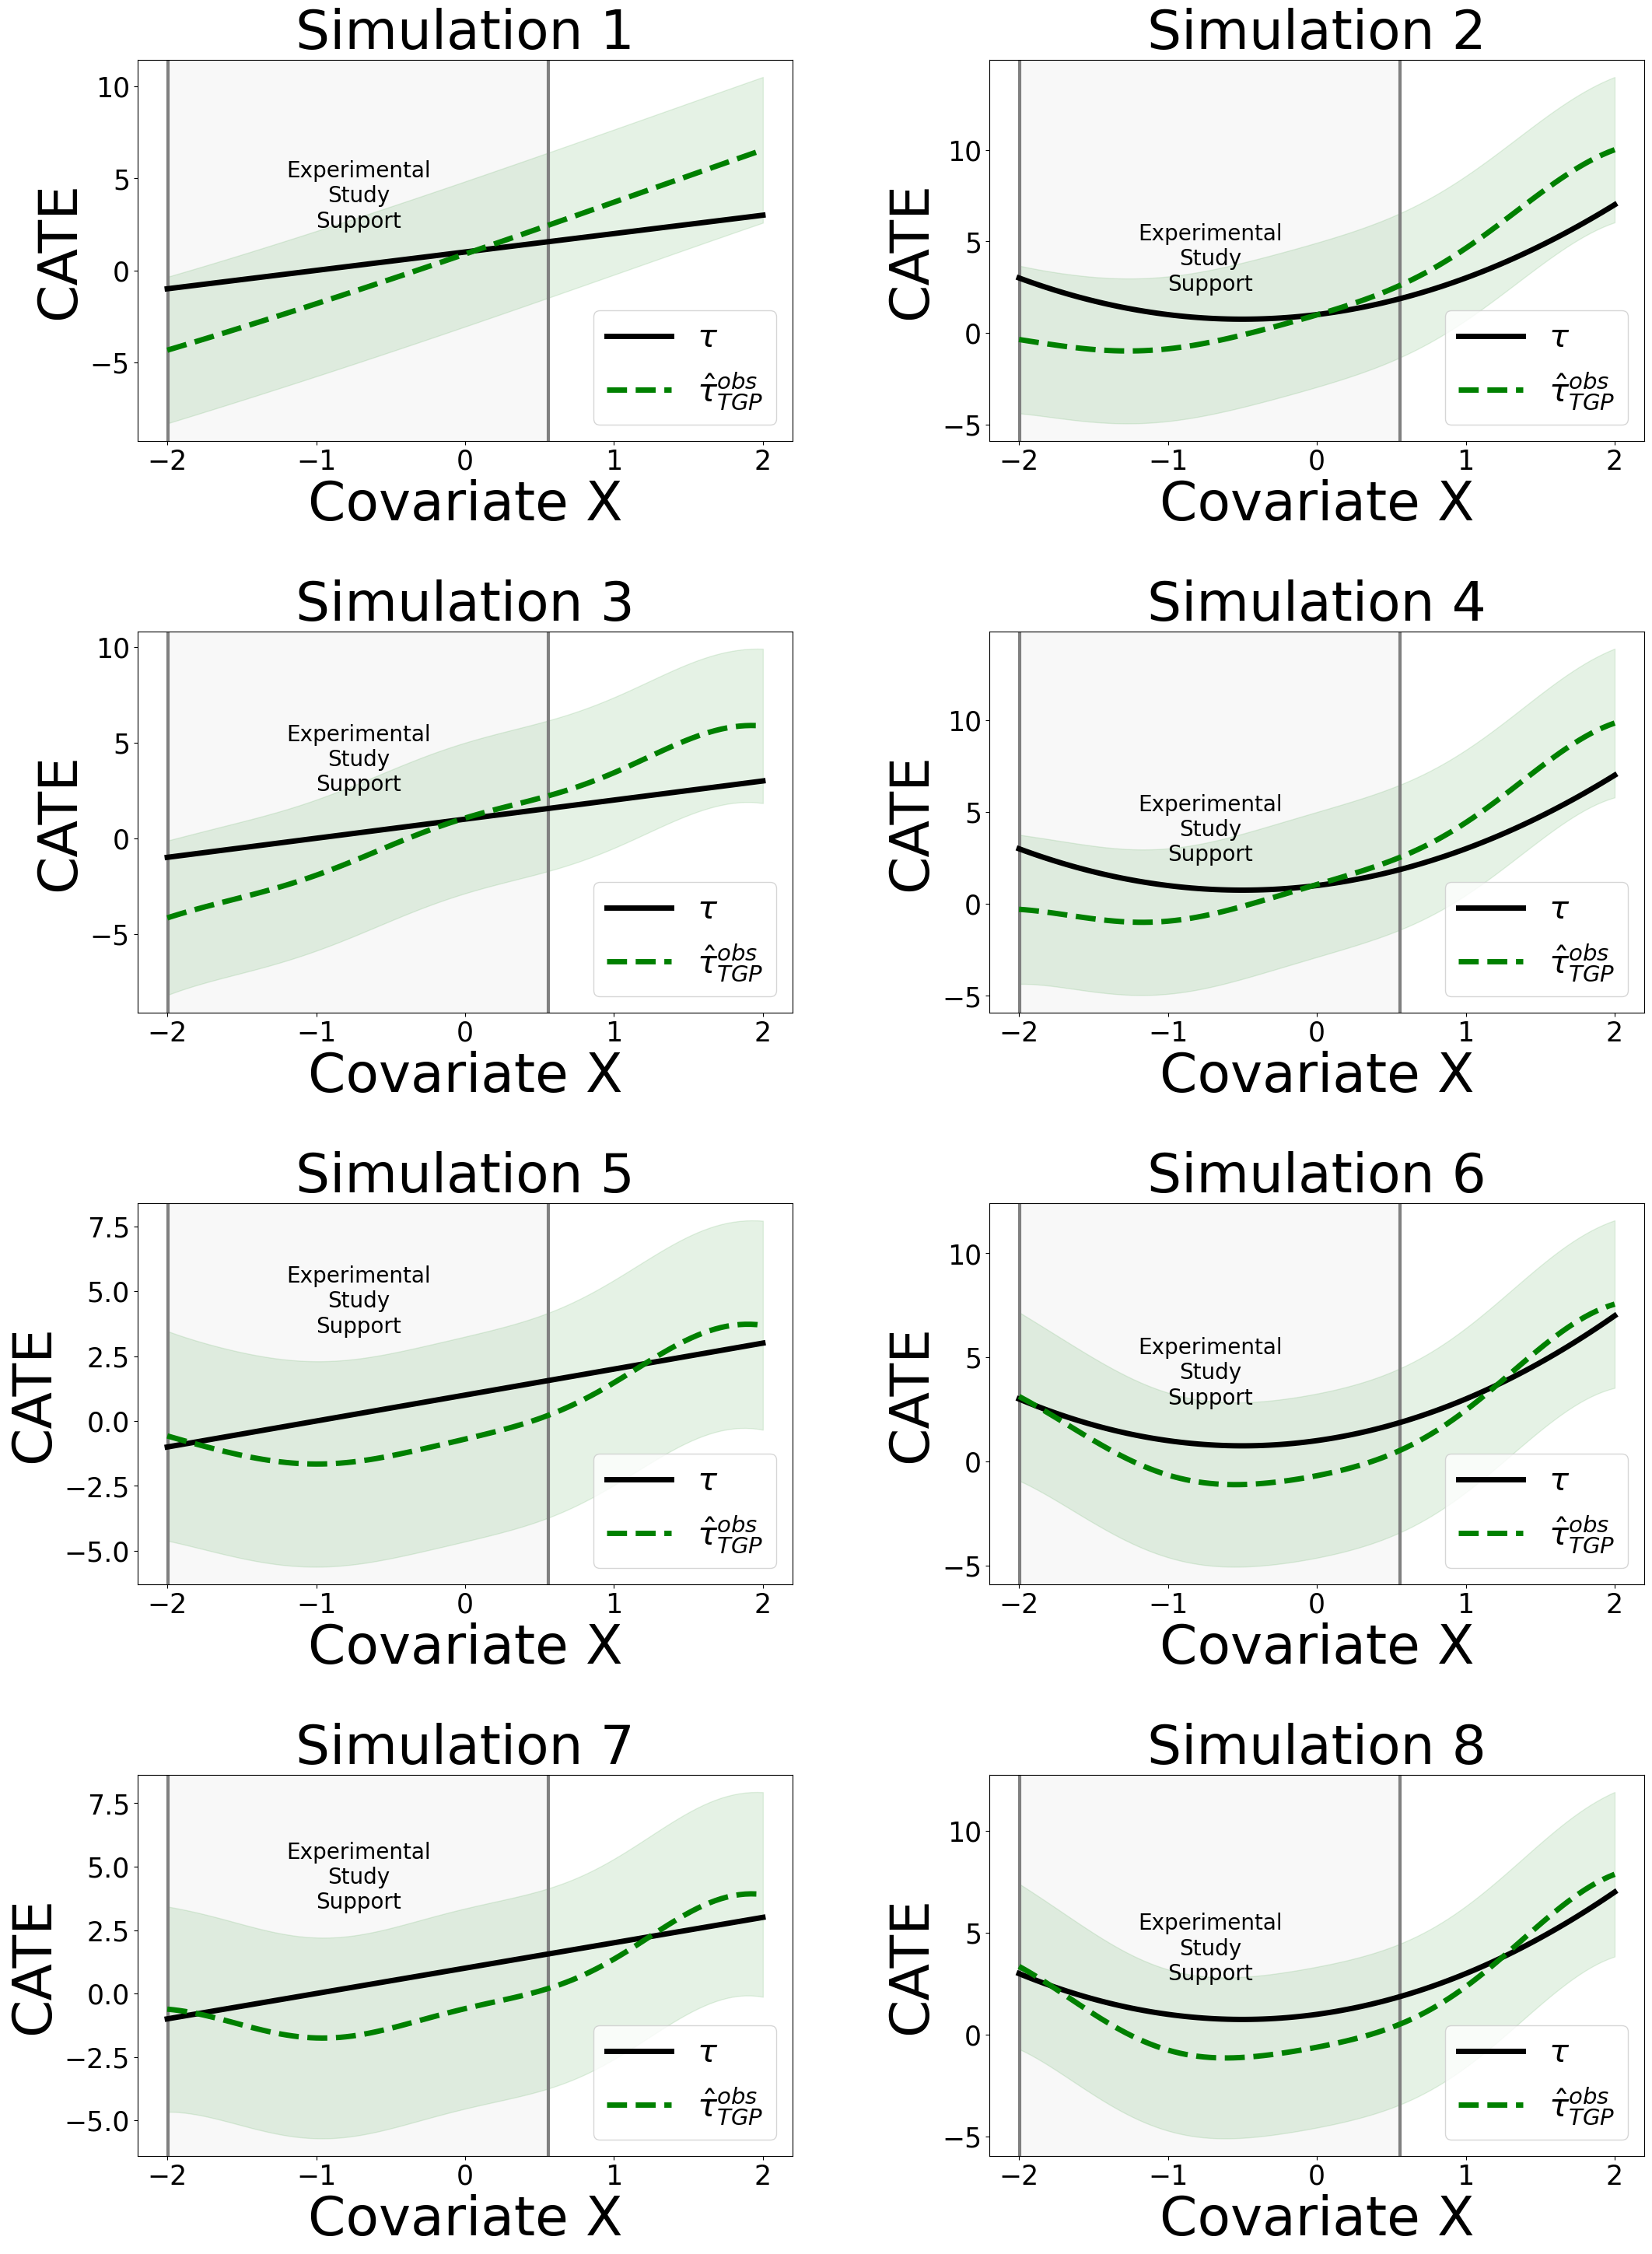

In [378]:
import matplotlib.pyplot as plt

# Initialize the figure and axes
fig, axes = plt.subplots(4, 2, figsize=(25, 35))

# Initialize a list to alternate between trueCATE1 and trueCATE2
cate_switch = [trueCATE1, trueCATE2] * 4

# Loop over all 8 models
for i in range(1, 9):
    # Plot for the current model
    ax = axes[(i - 1) // 2, (i - 1) % 2]

    # Extract the data for the current model
    list_naiveCATE_obs = zip(*sorted(zip(*(test_data, naiveCATEobs[i]))))
    list_CATE = zip(*sorted(zip(*(test_data, cate_switch[i - 1]))))  # Switch between trueCATE1 and trueCATE2

    # Plot settings
    ax.axvline(x=np.min(eval(f"data_exp{i}[:,1]")), c='grey', linewidth=3.0)
    ax.axvline(x=np.max(eval(f"data_exp{i}[:,1]")), c='grey', linewidth=3.0)
    ax.axvspan(np.min(eval(f"data_exp{i}[:,1]")), np.max(eval(f"data_exp{i}[:,1]")), alpha=0.05, color='grey')
    ax.text(((np.max(eval(f"data_exp{i}[:,1]")) + np.min(eval(f"data_exp{i}[:,1]")))/2), 6, 'Experimental\nStudy\nSupport', verticalalignment='top', horizontalalignment='center', size=20)
    ax.plot(*list_CATE, label='$\\tau$', c='black', linewidth=5.0)
    ax.plot(*list_naiveCATE_obs, label='$\\hat{\\tau}_{TGP}^{obs}$', c="green", linewidth=5.0, linestyle='dashed')
    ax.fill_between(test_data, 
                     np.hstack(naiveCATEobs[i]-1.96*np.vstack(np.sqrt(var_naiveCATEobs[i]))), 
                     np.hstack(naiveCATEobs[i]+1.96*np.vstack(np.sqrt(var_naiveCATEobs[i]))),
                    color="green", alpha=0.1)

    # Set labels and legend
    ax.set_xlabel("Covariate X", fontsize=50)
    ax.set_ylabel("CATE", fontsize=50)
    ax.legend(fontsize=30, loc='lower right')
    # Set larger font sizes for the axes ticks
    ax.tick_params(axis='x', labelsize=25)
    ax.tick_params(axis='y', labelsize=25)
    ax.set_title(f"Simulation {i}", fontsize=50)

# Adjust layout
plt.subplots_adjust(hspace=0.5, wspace=0.3)
# Show plot
plt.show()


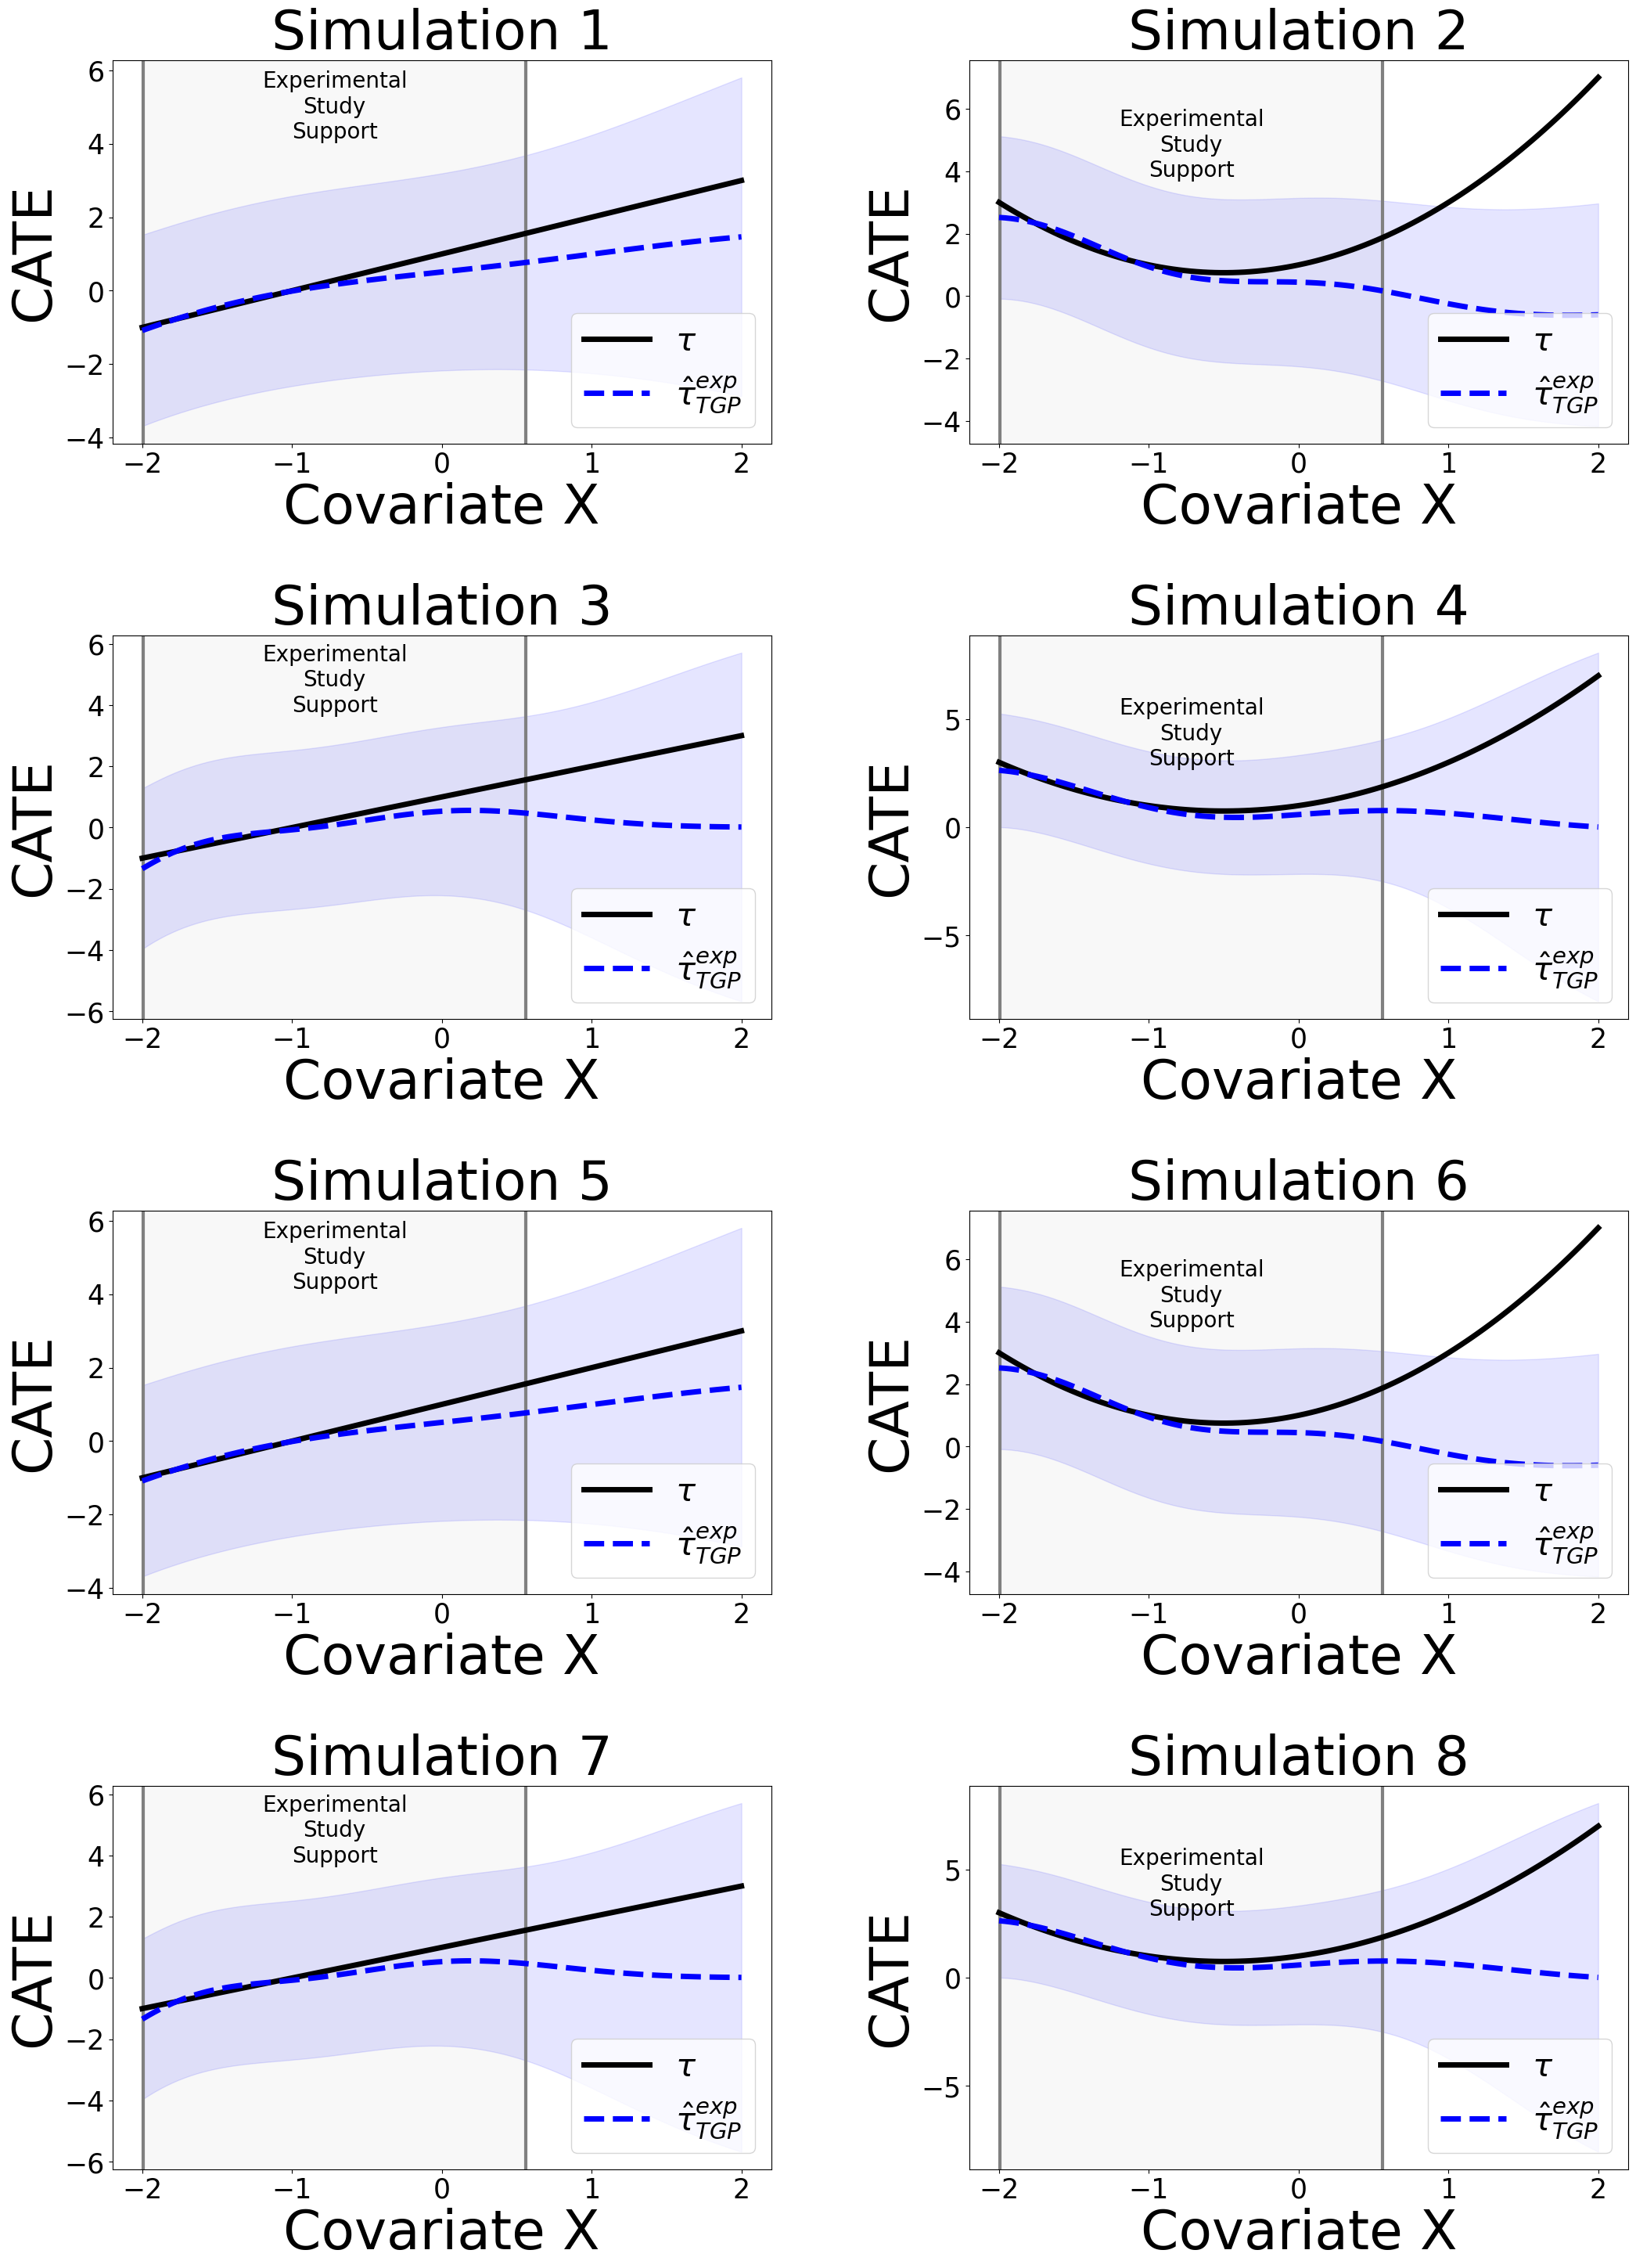

In [379]:
import matplotlib.pyplot as plt

# Initialize the figure and axes
fig, axes = plt.subplots(4, 2, figsize=(25, 35))

# Initialize a list to alternate between trueCATE1 and trueCATE2
cate_switch = [trueCATE1, trueCATE2] * 4

# Loop over all 8 models
for i in range(1, 9):
    # Plot for the current model
    ax = axes[(i - 1) // 2, (i - 1) % 2]

    # Extract the data for the current model
    list_naiveCATE_exp = zip(*sorted(zip(*(test_data, naiveCATEexp[i]))))
    list_CATE = zip(*sorted(zip(*(test_data, cate_switch[i - 1]))))  # Switch between trueCATE1 and trueCATE2

    # Plot settings
    ax.axvline(x=np.min(eval(f"data_exp{i}[:,1]")), c='grey', linewidth=3.0)
    ax.axvline(x=np.max(eval(f"data_exp{i}[:,1]")), c='grey', linewidth=3.0)
    ax.axvspan(np.min(eval(f"data_exp{i}[:,1]")), np.max(eval(f"data_exp{i}[:,1]")), alpha=0.05, color='grey')
    ax.text(((np.max(eval(f"data_exp{i}[:,1]")) + np.min(eval(f"data_exp{i}[:,1]")))/2), 6, 'Experimental\nStudy\nSupport', verticalalignment='top', horizontalalignment='center', size=20)
    ax.plot(*list_CATE, label='$\\tau$', c='black', linewidth=5.0)
    ax.plot(*list_naiveCATE_exp, label='$\\hat{\\tau}_{TGP}^{exp}$', c="blue", linewidth=5.0, linestyle='dashed')
    ax.fill_between(test_data, 
                     np.hstack(naiveCATEexp[i]-1.96*np.vstack(np.sqrt(var_naiveCATEexp[i]))), 
                     np.hstack(naiveCATEexp[i]+1.96*np.vstack(np.sqrt(var_naiveCATEexp[i]))),
                    color="blue", alpha=0.1)

    # Set labels and legend
    ax.set_xlabel("Covariate X", fontsize=50)
    ax.set_ylabel("CATE", fontsize=50)
    ax.legend(fontsize=30, loc='lower right')
    # Set larger font sizes for the axes ticks
    ax.tick_params(axis='x', labelsize=25)
    ax.tick_params(axis='y', labelsize=25)
    ax.set_title(f"Simulation {i}", fontsize=50)

# Adjust layout
plt.subplots_adjust(hspace=0.5, wspace=0.3)
# Show plot
plt.show()


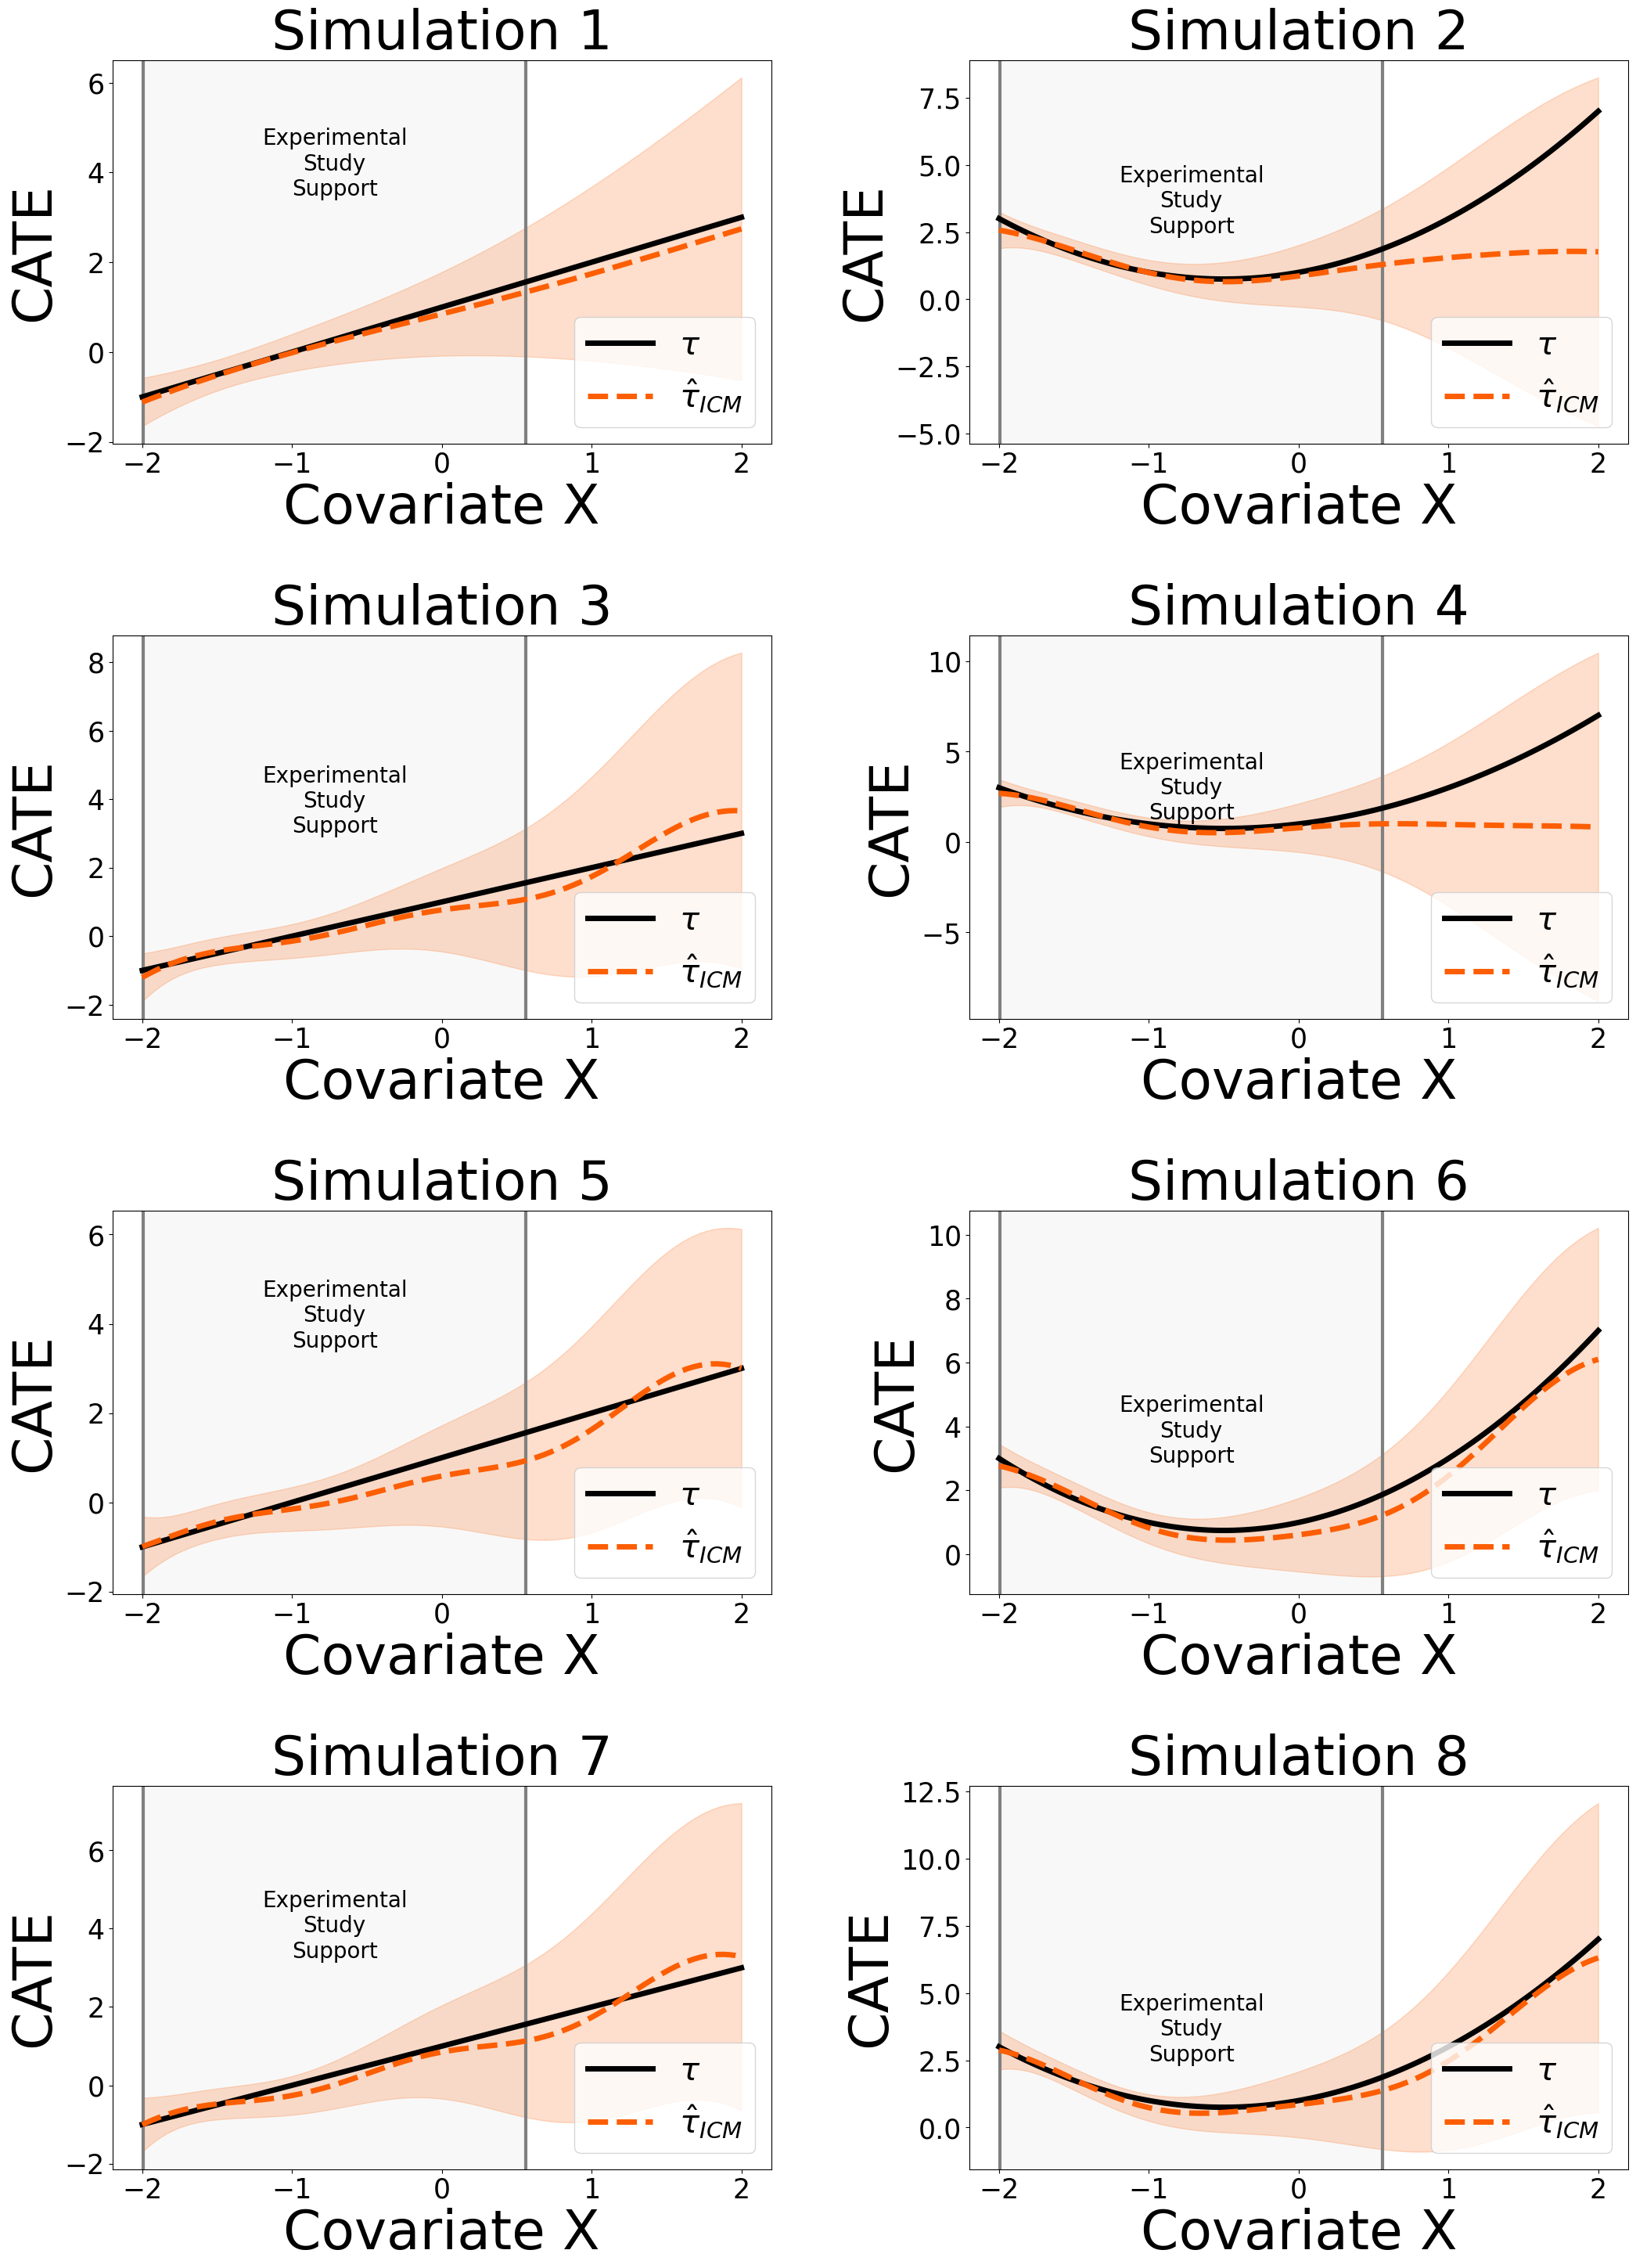

In [380]:
import matplotlib.pyplot as plt

# Initialize the figure and axes
fig, axes = plt.subplots(4, 2, figsize=(25, 35))

# Initialize a list to alternate between trueCATE1 and trueCATE2
cate_switch = [trueCATE1, trueCATE2] * 4

# Loop over all 8 models
for i in range(1, 9):
    # Plot for the current model
    ax = axes[(i - 1) // 2, (i - 1) % 2]

    # Extract the data for the current model
    list_naiveCATE_obs = zip(*sorted(zip(*(test_data, ICM_CATE[i]))))
    list_CATE = zip(*sorted(zip(*(test_data, cate_switch[i - 1]))))  # Switch between trueCATE1 and trueCATE2

    # Plot settings
    ax.axvline(x=np.min(eval(f"data_exp{i}[:,1]")), c='grey', linewidth=3.0)
    ax.axvline(x=np.max(eval(f"data_exp{i}[:,1]")), c='grey', linewidth=3.0)
    ax.axvspan(np.min(eval(f"data_exp{i}[:,1]")), np.max(eval(f"data_exp{i}[:,1]")), alpha=0.05, color='grey')
    ax.text(((np.max(eval(f"data_exp{i}[:,1]")) + np.min(eval(f"data_exp{i}[:,1]")))/2), 5, 'Experimental\nStudy\nSupport', verticalalignment='top', horizontalalignment='center', size=20)
    ax.plot(*list_CATE, label='$\\tau$', c='black', linewidth=5.0)
    ax.plot(*list_naiveCATE_obs, label='$\\hat{\\tau}_{ICM}$', c="#fc5e03", linewidth=5.0, linestyle='dashed')
    ax.fill_between(test_data, 
                     np.hstack(ICM_CATE[i]-1.96*np.vstack(np.sqrt(varICM_CATE[i]))), 
                     np.hstack(ICM_CATE[i]+1.96*np.vstack(np.sqrt(varICM_CATE[i]))),
                    color="#fc5e03", alpha=0.2)

    # Set labels and legend
    ax.set_xlabel("Covariate X", fontsize=50)
    ax.set_ylabel("CATE", fontsize=50)
    ax.legend(fontsize=30, loc='lower right')
    # Set larger font sizes for the axes ticks
    ax.tick_params(axis='x', labelsize=25)
    ax.tick_params(axis='y', labelsize=25)
    ax.set_title(f"Simulation {i}", fontsize=50)

# Adjust layout
plt.subplots_adjust(hspace=0.5, wspace=0.3)
# Show plot
plt.show()
